# CARMA joint QMLE, recovered Levy driver, and driver-distribution diagnostics

This notebook uses the CARMA order and the ACF-based initialization exported by `02order.ipynb`.

1. load the CARMA order and initial roots/coefficients selected in `02order.ipynb`;
2. jointly estimate the AR roots and MA roots by exact Gaussian prediction-error QMLE with an ACF penalty;
3. profile the Levy drift rate `m` and variance rate `nu2` from the exact Kalman/Riccati innovations;
4. recover hourly Levy driver increments `Delta L` from the smoothed CARMA state;
5. fit Gaussian and NIG laws to the recovered `Delta L`;
6. simulate the selected CARMA model driven by those fitted drivers and compare the simulated levels `Y_t` with the empirical deseasonalised log-price residuals.

Conventions:

- the CARMA order and root topology are fixed from notebook 02: three real AR roots and one complex-conjugate AR pair;
- the AR complex period is fixed to 24 hours; all other AR root half-lives are estimated;
- the MA polynomial is parameterised by two real negative roots and one stable complex-conjugate pair;
- the MA normalization is the notebook-02/book convention `b[-1] = 1`;
- `Delta L` denotes increments of the latent Levy driver.


In [2]:
%matplotlib inline

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import minimize
from scipy.special import kve
from scipy.stats import norm, norminvgauss
from numba import njit

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "germany" / "germany23+24+25" / "data" / "seasonality" / "german_panel.csv").exists():
    CODE = CWD / "germany" / "germany23+24+25"
elif (CWD / "data" / "seasonality" / "german_panel.csv").exists():
    CODE = CWD
else:
    raise FileNotFoundError("Run this notebook from the repo root or from germany/germany23+24+25/. Run notebook 01 first.")

DATA = CODE / "data"
OUT = DATA / "kalman"
FIG = CODE / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(DATA / "seasonality" / "german_panel.csv", index_col=0, parse_dates=True)
panel = panel.dropna(subset=["price_raw", "log_price", "log_price_seasonal", "log_price_resid"])

price_obs = panel["price_raw"].to_numpy(float)
log_price_obs = panel["log_price"].to_numpy(float)
log_price_seasonal = panel["log_price_seasonal"].to_numpy(float)
pr = panel["log_price_resid"].to_numpy(float)

valid = (
    np.isfinite(price_obs)
    & np.isfinite(log_price_obs)
    & np.isfinite(log_price_seasonal)
    & np.isfinite(pr)
)
panel = panel.loc[valid]
price_obs = price_obs[valid]
log_price_obs = log_price_obs[valid]
log_price_seasonal = log_price_seasonal[valid]
pr = pr[valid]

N = len(pr)
obs_delta_y = np.diff(pr)
obs_delta_log_price = np.diff(log_price_obs)
obs_delta_price = np.diff(price_obs)
price_shift = float(np.median(np.exp(log_price_obs) - price_obs))
seasonality_identity_error = float(np.max(np.abs(log_price_obs - log_price_seasonal - pr)))

print(f"{N:,} hourly deseasonalised log-price residuals")
print(f"Y empirical mean/std       = {pr.mean():.6e} / {pr.std(ddof=0):.6e}")
print(f"Delta Y empirical mean/std = {obs_delta_y.mean():.6e} / {obs_delta_y.std(ddof=0):.6e}")
print(f"log-price shift inferred   = {price_shift:.6f}")
print(f"max |log_price - seasonal - resid| = {seasonality_identity_error:.3e}")

26,305 hourly deseasonalised log-price residuals
Y empirical mean/std       = -4.644104e-07 / 3.545192e-02
Delta Y empirical mean/std = 2.432794e-06 / 1.295224e-02
log-price shift inferred   = 1000.000000
max |log_price - seasonal - resid| = 1.860e-15


## 1. CARMA state-space model and root parameterisation

The model order and starting point come from notebook 02. The optimisation below keeps the same root topology but estimates the half-lives of the AR roots and the stable MA roots.


In [3]:
def build_companion_matrix(ar_coefficients):
    ar = np.asarray(ar_coefficients, dtype=float)
    p = len(ar)
    A = np.zeros((p, p))
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -ar[::-1]

    expected = np.concatenate([[1.0], ar])
    actual = np.poly(np.linalg.eigvals(A)).real
    if not np.allclose(actual, expected, atol=1e-6):
        raise ValueError(f"Companion matrix check failed: {actual} vs {expected}")
    return A


def build_b_vector(b_coefficients, p):
    b = np.asarray(b_coefficients, dtype=float)
    q = len(b) - 1
    if q > p - 1:
        raise ValueError(f"q={q} must be <= p-1={p-1}")
    return np.concatenate([b, np.zeros(p - 1 - q)]) if q < p - 1 else b.copy()


def psd_sqrt(M, tol=1e-12):
    M = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M)
    if vals.min() < -tol:
        raise ValueError(f"Matrix is not PSD; min eigenvalue={vals.min():.3e}")
    return vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))


def discrete_noise_covariance(A, ep, Delta=1.0):
    # Van Loan block exponential for int_0^Delta exp(Au) e e' exp(A'u) du.
    A = np.asarray(A, dtype=float)
    ep = np.asarray(ep, dtype=float)
    p = A.shape[0]
    M = np.zeros((2 * p, 2 * p))
    M[:p, :p] = A
    M[:p, p:] = np.outer(ep, ep)
    M[p:, p:] = -A.T
    E = expm(M * Delta)
    F_block = E[:p, :p]
    Q = E[:p, p:] @ F_block.T
    return 0.5 * (Q + Q.T)


def distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    s = pd.Series(x)
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(ddof=0),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.quantile(0.50),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "skew": s.skew(),
        "excess_kurtosis": s.kurt(),
    })


def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    return np.array([1.0] + [float(np.dot(x[:-k], x[k:]) / denom) for k in range(1, max_lag + 1)])


def coeffs_from_roots(roots):
    return np.real_if_close(np.poly(np.asarray(roots, dtype=complex))[1:]).real


def b_coeffs_from_roots(roots):
    # np.poly returns descending coefficients. Reverse to b0, ..., bq and keep bq=1.
    return np.real_if_close(np.poly(np.asarray(roots, dtype=complex))[::-1]).real


def parse_roots_array(roots_payload):
    return np.array([complex(r[0], r[1]) for r in roots_payload], dtype=complex)


def half_life_from_kappa(kappa):
    return np.log(2.0) / np.asarray(kappa, dtype=float)


def kappa_from_half_life(half_life):
    return np.log(2.0) / np.asarray(half_life, dtype=float)


def split_real_and_complex_roots(roots_complex, tol=1e-8):
    roots_complex = np.asarray(roots_complex, dtype=complex)
    real_roots = np.sort(roots_complex[np.abs(roots_complex.imag) < tol].real)
    complex_pos = roots_complex[roots_complex.imag > tol]
    complex_pos = complex_pos[np.argsort(complex_pos.imag)]
    return real_roots, complex_pos


def make_state_space(ar_coeffs, b_coeffs, Delta=1.0):
    p_loc = len(ar_coeffs)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p_loc)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p_loc)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc_loc = float(b_coeffs[0] / ar_coeffs[-1])
    return A_loc, ep_loc, b_loc, F_loc, Pi1_loc, Qb_loc, dc_loc


with open(OUT / "price_multiscale_carma_selected.json") as f:
    cfg = json.load(f)

ar_init = np.array(cfg["ar_coefficients"], dtype=float)
b_init = np.array(cfg["b_coefficients"], dtype=float)
roots_init_complex = parse_roots_array(cfg["roots"])

p = len(ar_init)
q = len(b_init) - 1
Delta = 1.0
model_name = f"CARMA({p},{q})"
model_tag = f"carma{p}{q}"
omega_ar_fixed = 2.0 * np.pi / 24.0

if p != 5 or q != 4:
    raise ValueError(f"This notebook expects the Germany CARMA(5,4) topology; got CARMA({p},{q}).")

ar_real_init, ar_complex_init = split_real_and_complex_roots(roots_init_complex)
if len(ar_real_init) != 3 or len(ar_complex_init) != 1:
    raise ValueError("Expected three real AR roots and one complex-conjugate AR pair.")

ma_roots_init = np.roots(b_init[::-1])
ma_real_init, ma_complex_init = split_real_and_complex_roots(ma_roots_init)
if len(ma_real_init) != 2 or len(ma_complex_init) != 1:
    raise ValueError("Expected two real MA roots and one complex-conjugate MA pair.")

A, ep, b_vec, F, Pi1, Q_base, dc_gain = make_state_space(ar_init, b_init, Delta)
roots = np.column_stack([roots_init_complex.real, roots_init_complex.imag])
ar_coefficients = ar_init.copy()
b_coefficients = b_init.copy()
g_vec = np.linalg.solve(A, (F - np.eye(p)) @ ep)

print(model_name)
print("Initial AR roots:", np.array2string(roots_init_complex, precision=6))
print("Initial MA roots:", np.array2string(ma_roots_init, precision=6))
print(f"Initial b = {np.array2string(b_vec, precision=6)}")
print(f"max Re(AR root) = {roots_init_complex.real.max():.6e}")
print(f"max Re(MA root) = {ma_roots_init.real.max():.6e}")
print(f"Pi1 min eig     = {np.linalg.eigvalsh(Pi1).min():.3e}")
print(f"Qbase min eig   = {np.linalg.eigvalsh(Q_base).min():.3e}")
print(f"DC gain b(0)/a(0) = {dc_gain:.6e}")


CARMA(5,4)
Initial AR roots: [-2.634604e-01+0.j       -2.416095e-02+0.j       -2.406761e-04+0.j
 -4.003985e-03+0.261799j -4.003985e-03-0.261799j]
Initial MA roots: [-0.012799+0.261447j -0.012799-0.261447j -0.103749+0.j
 -0.001102+0.j      ]
Initial b = [7.835423e-06 7.187126e-03 7.131652e-02 1.304485e-01 1.000000e+00]
max Re(AR root) = -2.406761e-04
max Re(MA root) = -1.102234e-03
Pi1 min eig     = 1.682e+00
Qbase min eig   = 3.119e-08
DC gain b(0)/a(0) = 7.460385e+01


## 2. Exact Gaussian prediction-error QMLE with ACF penalty

This section implements the exact Gaussian prediction-error QMLE described in Section 19.1 of the CARMA QMLE chapter.

For fixed CARMA coefficients `(a,b)`, write the centred CARMA component as

```text
W_t = Y_t - m * b(0) / a(0).
```

The Kalman recursion is run with Levy variance normalised to one. At observation `i`, it returns:

```text
e_i = y_i - yhat_i        raw one-step prediction error before drift adjustment
r_i = Var(e_i)            innovation variance when nu2 = 1
```

Because the model mean enters as a constant shift, the adjusted innovation is linear in the Levy drift rate `m`:

```text
eps_i(m) = e_i - m * c_i,
c_i      = b(0)/a(0) times the innovation produced by filtering a constant-one series.
```

Therefore `m` is profiled exactly by weighted least squares:

```text
m_hat(a,b) = sum_i e_i c_i / r_i  /  sum_i c_i^2 / r_i.
```

Then the profiled Levy variance rate is the QMLE formula from equation 19.4:

```text
S(a,b,m_hat) = sum_i eps_i(m_hat)^2 / r_i
nu2_hat      = S / n.
```

The reduced likelihood from equation 19.5 is:

```text
ell_QMLE(a,b,m_hat) = log(S/n) + mean_i log(r_i).
```

The optimiser minimises this exact reduced likelihood plus a soft ACF penalty:

```text
objective = ell_QMLE + LAMBDA_ACF * mean_h [w_h * (rho_model(h) - rho_emp(h))]^2.
```

The ACF penalty is deliberately reported separately from the pure QMLE log-likelihood. `numba` is used only to compile the Riccati/Kalman loop; it does not change the likelihood, the profiling formulas, or the final estimator.


In [6]:
from numba import njit


@njit
def _profile_qmle_numba(y, F, Q_base, Pi1, b_vec, dc_gain):
    n = y.shape[0]
    p_loc = b_vec.shape[0]

    U_y = np.zeros(p_loc)
    U_c = np.zeros(p_loc)
    U_y_new = np.zeros(p_loc)
    U_c_new = np.zeros(p_loc)

    Pi = Pi1.copy()
    Psi = np.zeros((p_loc, p_loc))
    Omega = Pi1.copy()

    Omega_b = np.zeros(p_loc)
    Theta = np.zeros(p_loc)
    temp_pi = np.zeros((p_loc, p_loc))
    temp_psi = np.zeros((p_loc, p_loc))
    Pi_new = np.zeros((p_loc, p_loc))
    Psi_new = np.zeros((p_loc, p_loc))
    Omega_new = np.zeros((p_loc, p_loc))

    e_raw = np.empty(n)
    coef = np.empty(n)
    r_array = np.empty(n)
    residuals = np.empty(n)

    sum_log_r = 0.0
    sum_e_coef_over_r = 0.0
    sum_coef2_over_r = 0.0

    for i in range(n):
        for j in range(p_loc):
            s = 0.0
            for k in range(p_loc):
                s += Omega[j, k] * b_vec[k]
            Omega_b[j] = s

        Delta_i = 0.0
        for j in range(p_loc):
            Delta_i += b_vec[j] * Omega_b[j]

        if Delta_i <= 0.0 or not np.isfinite(Delta_i):
            return 0.0, 0.0, 0.0, 0.0, r_array, residuals, e_raw, coef, 1

        for j in range(p_loc):
            s = 0.0
            for k in range(p_loc):
                s += F[j, k] * Omega_b[k]
            Theta[j] = s

        pred_y = 0.0
        pred_c = 0.0
        for j in range(p_loc):
            pred_y += b_vec[j] * U_y[j]
            pred_c += b_vec[j] * U_c[j]

        e_i = y[i] - pred_y
        c_i = dc_gain * (1.0 - pred_c)
        inv_delta = 1.0 / Delta_i

        e_raw[i] = e_i
        coef[i] = c_i
        r_array[i] = Delta_i
        sum_log_r += np.log(Delta_i)
        sum_e_coef_over_r += e_i * c_i * inv_delta
        sum_coef2_over_r += c_i * c_i * inv_delta

        for j in range(p_loc):
            sy = 0.0
            sc = 0.0
            for k in range(p_loc):
                sy += F[j, k] * U_y[k]
                sc += F[j, k] * U_c[k]
            U_y_new[j] = sy + Theta[j] * inv_delta * e_i
            U_c_new[j] = sc + Theta[j] * inv_delta * (1.0 - pred_c)

        for j in range(p_loc):
            for k in range(p_loc):
                spi = 0.0
                sps = 0.0
                for ell in range(p_loc):
                    spi += F[j, ell] * Pi[ell, k]
                    sps += F[j, ell] * Psi[ell, k]
                temp_pi[j, k] = spi
                temp_psi[j, k] = sps

        for j in range(p_loc):
            for k in range(p_loc):
                spi = Q_base[j, k]
                sps = Theta[j] * Theta[k] * inv_delta
                for ell in range(p_loc):
                    spi += temp_pi[j, ell] * F[k, ell]
                    sps += temp_psi[j, ell] * F[k, ell]
                Pi_new[j, k] = spi
                Psi_new[j, k] = sps

        for j in range(p_loc):
            for k in range(p_loc):
                Omega_new[j, k] = 0.5 * (
                    Pi_new[j, k] - Psi_new[j, k] + Pi_new[k, j] - Psi_new[k, j]
                )

        for j in range(p_loc):
            U_y[j] = U_y_new[j]
            U_c[j] = U_c_new[j]
            for k in range(p_loc):
                Pi[j, k] = Pi_new[j, k]
                Psi[j, k] = Psi_new[j, k]
                Omega[j, k] = Omega_new[j, k]

    if sum_coef2_over_r <= 0.0 or not np.isfinite(sum_coef2_over_r):
        return 0.0, 0.0, 0.0, 0.0, r_array, residuals, e_raw, coef, 2

    m_hat = sum_e_coef_over_r / sum_coef2_over_r

    S = 0.0
    for i in range(n):
        residuals[i] = e_raw[i] - m_hat * coef[i]
        S += residuals[i] * residuals[i] / r_array[i]

    nu2_hat = S / n
    if nu2_hat <= 0.0 or not np.isfinite(nu2_hat):
        return m_hat, 0.0, 0.0, 0.0, r_array, residuals, e_raw, coef, 3

    reduced_likelihood = np.log(nu2_hat) + sum_log_r / n
    loglik = -0.5 * (n * np.log(2.0 * np.pi * nu2_hat) + sum_log_r + n)

    return m_hat, nu2_hat, reduced_likelihood, loglik, r_array, residuals, e_raw, coef, 0


def estimate_m_nu2_from_state(y, F, Q_base, Pi1, b_vec, dc_gain):
    out = _profile_qmle_numba(
        np.asarray(y, dtype=np.float64),
        np.asarray(F, dtype=np.float64),
        np.asarray(Q_base, dtype=np.float64),
        np.asarray(Pi1, dtype=np.float64),
        np.asarray(b_vec, dtype=np.float64),
        float(dc_gain),
    )
    m_hat, nu2_hat, redlik, loglik, r, residuals, e_raw, coef, status = out
    if status != 0:
        raise RuntimeError(f"Numba QMLE recursion failed with status {status}.")

    return {
        "m_hat": float(m_hat),
        "nu2_hat": float(nu2_hat),
        "loglik": float(loglik),
        "reduced_likelihood": float(redlik),
        "r_array": np.asarray(r),
        "residuals": np.asarray(residuals),
        "e_raw": np.asarray(e_raw),
        "coef": np.asarray(coef),
    }


def estimate_m_nu2(y, ar_coeffs, b_coeffs, Delta=1.0):
    A_loc, ep_loc, b_loc, F_loc, Pi1_loc, Qb_loc, dc_loc = make_state_space(
        ar_coeffs, b_coeffs, Delta
    )
    return estimate_m_nu2_from_state(y, F_loc, Qb_loc, Pi1_loc, b_loc, dc_loc)


AR_DAILY_HALF_LIFE_FIXED_H = float(half_life_from_kappa(-ar_complex_init[0].real))
AR_DAILY_KAPPA_FIXED = float(kappa_from_half_life(AR_DAILY_HALF_LIFE_FIXED_H))

print(f"Fixed AR daily half-life from 02 = {AR_DAILY_HALF_LIFE_FIXED_H:.6f} h")
print(f"Fixed AR daily real part         = {-AR_DAILY_KAPPA_FIXED:.12e}")
print(f"Fixed AR daily period            = {2.0 * np.pi / omega_ar_fixed:.6f} h")


def theta_from_initial_roots():
    ar_real_hl = half_life_from_kappa(-ar_real_init)
    ar_real_hl = ar_real_hl[np.argsort(ar_real_hl)]  # fast, mid, slow at init only

    ma_real_hl = np.sort(half_life_from_kappa(-ma_real_init))
    ma_complex_hl = float(half_life_from_kappa(-ma_complex_init[0].real))
    ma_complex_omega = float(abs(ma_complex_init[0].imag))

    return np.r_[
        np.log(ar_real_hl),
        np.log(ma_real_hl),
        np.log(ma_complex_hl),
        ma_complex_omega,
    ]


def unpack_theta(theta):
    theta = np.asarray(theta, dtype=float)

    ar_fast_hl = float(np.exp(theta[0]))
    ar_mid_hl = float(np.exp(theta[1]))
    ar_slow_hl = float(np.exp(theta[2]))

    ma_real_hl = np.sort(np.exp(theta[3:5]))
    ma_complex_hl = float(np.exp(theta[5]))
    ma_complex_omega = float(theta[6])

    ar_real_kappa = kappa_from_half_life([ar_fast_hl, ar_mid_hl, ar_slow_hl])
    ma_real_kappa = kappa_from_half_life(ma_real_hl)
    ma_complex_kappa = float(kappa_from_half_life(ma_complex_hl))

    ar_roots = np.array([
        -ar_real_kappa[0],
        -ar_real_kappa[1],
        -ar_real_kappa[2],
        complex(-AR_DAILY_KAPPA_FIXED, omega_ar_fixed),
        complex(-AR_DAILY_KAPPA_FIXED, -omega_ar_fixed),
    ], dtype=complex)

    ma_roots = np.array([
        -ma_real_kappa[0],
        -ma_real_kappa[1],
        complex(-ma_complex_kappa, ma_complex_omega),
        complex(-ma_complex_kappa, -ma_complex_omega),
    ], dtype=complex)

    ar_coeffs = coeffs_from_roots(ar_roots)
    b_coeffs = b_coeffs_from_roots(ma_roots)
    return ar_roots, ma_roots, ar_coeffs, b_coeffs


def acf_model_from_state(A, b_vec, Pi1, lags):
    Pb = Pi1 @ b_vec
    var0 = float(b_vec @ Pb)
    if var0 <= 0 or not np.isfinite(var0):
        raise RuntimeError("Invalid CARMA variance for ACF.")

    vals, vecs = np.linalg.eig(A)
    Vinv = np.linalg.inv(vecs)
    left = b_vec @ vecs
    right = Vinv @ Pb
    expo = np.exp(np.outer(np.asarray(lags, dtype=float), vals))
    rho = expo @ (left * right) / var0
    return np.real_if_close(rho).real


def empirical_acf_values(y, lags):
    y = np.asarray(y, dtype=float)
    y = y - y.mean()
    v0 = float(np.dot(y, y) / len(y))
    return np.array([
        float(np.dot(y[:-int(k)], y[int(k):]) / ((len(y) - int(k)) * v0))
        for k in lags
    ])


lags_acf = np.arange(1, 337)
rho_emp_acf = empirical_acf_values(pr, lags_acf)

wts_acf = 1.0 / np.sqrt(lags_acf.astype(float))
wts_acf[lags_acf <= 72] *= 2.0
for anchor in [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]:
    wts_acf[lags_acf == anchor] *= 6.0
sw_acf = np.sqrt(wts_acf / wts_acf.mean())


LAMBDA_ACF = 10
N_RESTARTS = 12
MAXITER = 350
SD_LOG_HL = 0.25
SD_OMEGA_MA = 0.025

AR_FAST_BOUNDS_H = (0.2, 6)
AR_MID_BOUNDS_H = (2.0, 48.0)
AR_SLOW_BOUNDS_H = (1680.0, 4320.0)

MA_REAL_BOUNDS_H = (0.3, 720.0)
MA_COMPLEX_HL_BOUNDS_H = (0.3, 720.0)
MA_COMPLEX_OMEGA_BOUNDS = (1e-4, np.pi - 1e-4)

theta0 = theta_from_initial_roots()

lower = np.r_[
    np.log(AR_FAST_BOUNDS_H[0]),
    np.log(AR_MID_BOUNDS_H[0]),
    np.log(AR_SLOW_BOUNDS_H[0]),
    [np.log(MA_REAL_BOUNDS_H[0])] * 2,
    np.log(MA_COMPLEX_HL_BOUNDS_H[0]),
    MA_COMPLEX_OMEGA_BOUNDS[0],
]

upper = np.r_[
    np.log(AR_FAST_BOUNDS_H[1]),
    np.log(AR_MID_BOUNDS_H[1]),
    np.log(AR_SLOW_BOUNDS_H[1]),
    [np.log(MA_REAL_BOUNDS_H[1])] * 2,
    np.log(MA_COMPLEX_HL_BOUNDS_H[1]),
    MA_COMPLEX_OMEGA_BOUNDS[1],
]

bounds = list(zip(lower, upper))

print("Initial labelled AR half-lives:")
print(f"  fast  = {np.exp(theta0[0]):.3f} h")
print(f"  mid   = {np.exp(theta0[1]):.3f} h")
print(f"  slow  = {np.exp(theta0[2]):.3f} h")
print(f"  daily = {AR_DAILY_HALF_LIFE_FIXED_H:.3f} h fixed")


def joint_qmle_objective(theta, return_details=False):
    try:
        ar_roots_c, ma_roots_c, ar_c, b_c = unpack_theta(theta)

        if np.max(ar_roots_c.real) >= -1e-8 or np.max(ma_roots_c.real) >= -1e-8:
            raise RuntimeError("Non-causal or non-invertible roots.")
        if not np.all(np.isfinite(ar_c)) or not np.all(np.isfinite(b_c)):
            raise RuntimeError("Invalid polynomial coefficients.")

        A_c, ep_c, b_vec_c, F_c, Pi1_c, Q_c, dc_c = make_state_space(ar_c, b_c, Delta)
        qmle_c = estimate_m_nu2_from_state(pr, F_c, Q_c, Pi1_c, b_vec_c, dc_c)
        rho_mod_c = acf_model_from_state(A_c, b_vec_c, Pi1_c, lags_acf)

        acf_mse = float(np.mean((sw_acf * (rho_mod_c - rho_emp_acf)) ** 2))
        obj = qmle_c["reduced_likelihood"] + LAMBDA_ACF * acf_mse

        if not np.isfinite(obj):
            raise RuntimeError("Invalid objective.")

        if return_details:
            return {
                "objective": float(obj),
                "acf_mse": acf_mse,
                "qmle": qmle_c,
                "ar_roots": ar_roots_c,
                "ma_roots": ma_roots_c,
                "ar_coefficients": ar_c,
                "b_coefficients": b_c,
                "rho_model": rho_mod_c,
            }
        return float(obj)

    except Exception as exc:
        if return_details:
            return {"objective": 1e50, "error": str(exc)}
        return 1e50


init_details = joint_qmle_objective(theta0, return_details=True)

print("\n=== Initial exact QMLE from notebook 02 ===")
print(f"reduced likelihood = {init_details['qmle']['reduced_likelihood']:.8f}")
print(f"loglik             = {init_details['qmle']['loglik']:.3f}")
print(f"m, nu2             = {init_details['qmle']['m_hat']:.6e}, {init_details['qmle']['nu2_hat']:.6e}")
print(f"ACF weighted MSE   = {init_details['acf_mse']:.6e}")
print(f"penalized objective= {init_details['objective']:.8f}")

rng = np.random.default_rng(42)
best = None
restart_rows = []

for i in range(N_RESTARTS):
    if i == 0:
        start = theta0.copy()
    else:
        start = theta0.copy()
        start[:6] += rng.normal(0.0, SD_LOG_HL, size=6)
        start[6] += rng.normal(0.0, SD_OMEGA_MA)
        start = np.clip(start, lower, upper)

    res = minimize(
        joint_qmle_objective,
        start,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": MAXITER, "ftol": 1e-9, "maxls": 30},
    )

    details = joint_qmle_objective(res.x, return_details=True)
    restart_rows.append({
        "restart": i + 1,
        "success": bool(res.success),
        "objective": details["objective"],
        "loglik": details["qmle"]["loglik"] if "qmle" in details else np.nan,
        "acf_mse": details.get("acf_mse", np.nan),
        "message": str(res.message),
    })

    print(
        f"restart {i + 1:02d}: obj={details['objective']:.8f} "
        f"loglik={restart_rows[-1]['loglik']:.3f} "
        f"acf_mse={restart_rows[-1]['acf_mse']:.3e} success={res.success}"
    )

    if best is None or details["objective"] < best["details"]["objective"]:
        best = {"res": res, "details": details}


opt = best["details"]

ar_coefficients = opt["ar_coefficients"].copy()
b_coefficients = opt["b_coefficients"].copy()
roots_complex = opt["ar_roots"].copy()
ma_roots_complex = opt["ma_roots"].copy()
roots = np.column_stack([roots_complex.real, roots_complex.imag])

A, ep, b_vec, F, Pi1, Q_base, dc_gain = make_state_space(ar_coefficients, b_coefficients, Delta)
g_vec = np.linalg.solve(A, (F - np.eye(p)) @ ep)

qmle = opt["qmle"]
m_hat = qmle["m_hat"]
nu2_hat = qmle["nu2_hat"]
r_array = qmle["r_array"]
eps_adj = qmle["residuals"]
eps_std = eps_adj / np.sqrt(nu2_hat * r_array)

ar_real_opt, ar_complex_opt = split_real_and_complex_roots(roots_complex)
ma_real_opt, ma_complex_opt = split_real_and_complex_roots(ma_roots_complex)

ar_half_lives_h = half_life_from_kappa(-ar_real_opt)
ar_complex_half_life_h = float(half_life_from_kappa(-ar_complex_opt[0].real))
ma_half_lives_h = half_life_from_kappa(-ma_real_opt)
ma_complex_half_life_h = float(half_life_from_kappa(-ma_complex_opt[0].real))
ma_complex_period_h = float(2.0 * np.pi / abs(ma_complex_opt[0].imag))

restart_df = pd.DataFrame(restart_rows)
restart_path = OUT / f"price_{model_tag}_joint_qmle_restarts.csv"
restart_df.to_csv(restart_path, index=False)

qmle_json = {
    "m_qmle": float(m_hat),
    "nu2_qmle": float(nu2_hat),
    "loglik_qmle": float(qmle["loglik"]),
    "reduced_likelihood_qmle": float(qmle["reduced_likelihood"]),
    "acf_weighted_mse": float(opt["acf_mse"]),
    "penalized_objective": float(opt["objective"]),
    "lambda_acf": float(LAMBDA_ACF),
    "stationary_mean": float(m_hat * dc_gain),
    "carma_order": [int(p), int(q)],
    "ar_coefficients": [float(x) for x in ar_coefficients],
    "b_coefficients": [float(x) for x in b_coefficients],
    "ar_roots": [[float(z.real), float(z.imag)] for z in roots_complex],
    "ma_roots": [[float(z.real), float(z.imag)] for z in ma_roots_complex],
    "ar_real_half_lives_h": [float(x) for x in ar_half_lives_h],
    "ar_complex_half_life_h": float(ar_complex_half_life_h),
    "ar_complex_period_h": 24.0,
    "ar_complex_half_life_fixed_from_02": float(AR_DAILY_HALF_LIFE_FIXED_H),
    "ma_real_half_lives_h": [float(x) for x in ma_half_lives_h],
    "ma_complex_half_life_h": float(ma_complex_half_life_h),
    "ma_complex_period_h": float(ma_complex_period_h),
    "source": "germany/germany23+24+25/03mle.ipynb",
    "note": "Joint exact Riccati QMLE over labelled real AR roots and MA roots; AR daily root fixed from notebook 02; b[-1]=1.",
}

qmle_path = OUT / f"price_{model_tag}_joint_qmle_result.json"
qmle_path.write_text(json.dumps(qmle_json, indent=2))
(OUT / "price_carma_qmle_result.json").write_text(json.dumps(qmle_json, indent=2))

print("\n=== Final joint exact QMLE with ACF penalty ===")
print(f"penalized objective = {opt['objective']:.8f}")
print(f"pure QMLE loglik    = {qmle['loglik']:.3f}")
print(f"reduced likelihood  = {qmle['reduced_likelihood']:.8f}")
print(f"ACF weighted MSE    = {opt['acf_mse']:.6e}")
print(f"m_hat               = {m_hat:.6e}")
print(f"nu2_hat             = {nu2_hat:.6e}  sqrt={np.sqrt(nu2_hat):.6e}")
print(f"stationary mean Y   = {m_hat * dc_gain:.6e}")
print(f"standardised innovations mean/std = {eps_std.mean():.4f} / {eps_std.std(ddof=0):.4f}")

print("\nAR roots and half-lives")
for z in roots_complex:
    if abs(z.imag) < 1e-8:
        hl = np.log(2.0) / (-z.real)
        print(f"  real     lambda={z.real:+.6e}  half-life={hl:.3f} h ({hl / 24.0:.3f} d)")
    elif z.imag > 0:
        hl = np.log(2.0) / (-z.real)
        period = 2.0 * np.pi / abs(z.imag)
        print(
            f"  complex  lambda={z.real:+.6e} +/- {abs(z.imag):.6e}i  "
            f"half-life={hl:.3f} h ({hl / 24.0:.3f} d), period={period:.3f} h"
        )

print("\nMA roots")
for z in ma_roots_complex:
    if abs(z.imag) < 1e-8:
        hl = np.log(2.0) / (-z.real)
        print(f"  real     root={z.real:+.6e}  half-life={hl:.3f} h ({hl / 24.0:.3f} d)")
    elif z.imag > 0:
        hl = np.log(2.0) / (-z.real)
        period = 2.0 * np.pi / abs(z.imag)
        print(
            f"  complex  root={z.real:+.6e} +/- {abs(z.imag):.6e}i  "
            f"half-life={hl:.3f} h ({hl / 24.0:.3f} d), period={period:.3f} h"
        )

print(f"\nSaved: {qmle_path.name}")
print(f"Saved: {restart_path.name}")

Fixed AR daily half-life from 02 = 173.114350 h
Fixed AR daily real part         = -4.003984536373e-03
Fixed AR daily period            = 24.000000 h
Initial labelled AR half-lives:
  fast  = 2.631 h
  mid   = 28.689 h
  slow  = 2880.000 h
  daily = 173.114 h fixed

=== Initial exact QMLE from notebook 02 ===
reduced likelihood = -8.73498304
loglik             = 77561.686
m, nu2             = 1.396680e-05, 1.879996e-04
ACF weighted MSE   = 5.819978e-04
penalized objective= -8.72916306
restart 01: obj=-8.73918538 loglik=77709.299 acf_mse=7.021e-04 success=True
restart 02: obj=-8.73919045 loglik=77709.323 acf_mse=7.018e-04 success=True
restart 03: obj=-8.73919275 loglik=77709.320 acf_mse=7.015e-04 success=True
restart 04: obj=-8.73917628 loglik=77709.219 acf_mse=7.024e-04 success=True
restart 05: obj=-8.73918696 loglik=77709.277 acf_mse=7.018e-04 success=True
restart 06: obj=-8.73915945 loglik=77708.932 acf_mse=7.019e-04 success=True
restart 07: obj=-8.73919351 loglik=77709.340 acf_mse=7

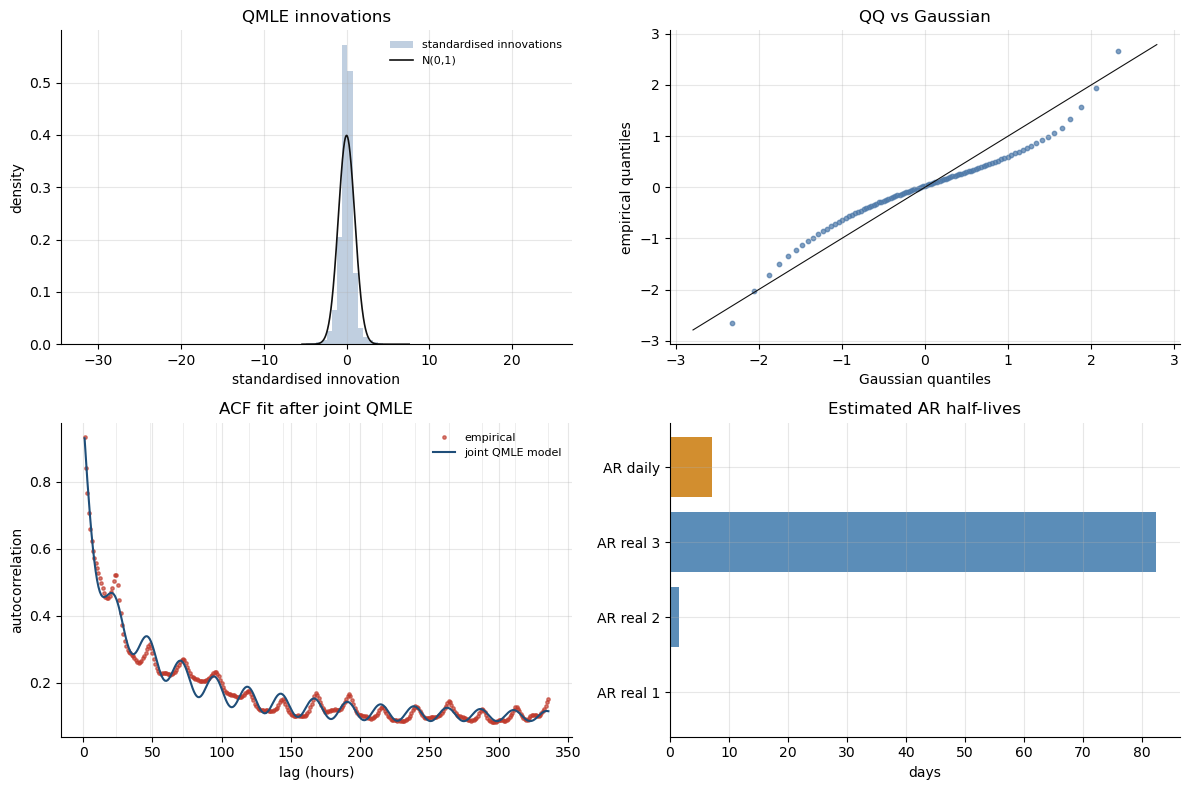

Saved: price_carma54_joint_qmle_diagnostics.png


In [7]:
rho_model_final = opt["rho_model"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.hist(eps_std, bins=90, density=True, color="#4c78a8", alpha=0.35, label="standardised innovations")
x = np.linspace(np.quantile(eps_std, 0.001), np.quantile(eps_std, 0.999), 600)
ax.plot(x, norm.pdf(x), color="#111111", lw=1.2, label="N(0,1)")
ax.set_title("QMLE innovations")
ax.set_xlabel("standardised innovation")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
probs = np.linspace(0.01, 0.99, 99)
emp_q = np.quantile(eps_std, probs)
norm_q = norm.ppf(probs)
lim = max(abs(emp_q).max(), abs(norm_q).max()) * 1.05
ax.scatter(norm_q, emp_q, s=10, color="#4c78a8", alpha=0.7)
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("QQ vs Gaussian")
ax.set_xlabel("Gaussian quantiles")
ax.set_ylabel("empirical quantiles")

ax = axes[1, 0]
ax.plot(lags_acf, rho_emp_acf, "o", ms=2.4, color="#c0392b", alpha=0.65, label="empirical")
ax.plot(lags_acf, rho_model_final, "-", lw=1.5, color="#1f4e79", label="joint QMLE model")
for hline in range(24, 337, 24):
    ax.axvline(hline, color="#eeeeee", lw=0.7, zorder=0)
ax.set_title("ACF fit after joint QMLE")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
hl_labels = ["AR real 1", "AR real 2", "AR real 3", "AR daily"]
hl_vals = list(ar_half_lives_h) + [ar_complex_half_life_h]
ax.barh(hl_labels, np.asarray(hl_vals) / 24.0, color=["#5b8db8", "#5b8db8", "#5b8db8", "#d28e2f"])
ax.set_title("Estimated AR half-lives")
ax.set_xlabel("days")

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_joint_qmle_diagnostics.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


In [8]:
# Discrete-time ARMA(5,4) benchmark on deseasonalised log-price residuals

import statsmodels.api as sm

y_arma = np.asarray(pr, dtype=float)
y_arma = y_arma[np.isfinite(y_arma)]
y_arma = y_arma - y_arma.mean()

arma54 = sm.tsa.SARIMAX(
    y_arma,
    order=(1, 0, 0),
    trend="n",
    enforce_stationarity=True,
    enforce_invertibility=True,
)

arma54_res = arma54.fit(
    method="lbfgs",
    maxiter=1000,
    disp=False,
)

print("=== Discrete ARMA(5,4) benchmark on log_price_resid ===")
print(f"loglik = {arma54_res.llf:.6f}")
print(f"AIC    = {arma54_res.aic:.6f}")
print(f"BIC    = {arma54_res.bic:.6f}")
print(f"nobs   = {arma54_res.nobs}")
print("\nParameters:")
print(arma54_res.params)

print("\nRoots:")
print("AR roots modulus:", np.round(np.abs(arma54_res.arroots), 6))
print("MA roots modulus:", np.round(np.abs(arma54_res.maroots), 6))

display(pd.DataFrame({
    "param": arma54_res.param_names,
    "value": arma54_res.params,
}))

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== Discrete ARMA(5,4) benchmark on log_price_resid ===
loglik = 77454.049555
AIC    = -154904.099110
BIC    = -154887.744081
nobs   = 26305

Parameters:
[9.33190392e-01 1.62150409e-04]

Roots:
AR roots modulus: [1.071593]
MA roots modulus: []


,param,value
0,ar.L1,0.933190
1,sigma2,0.000162


In [9]:
# Final QMLE parameter report with half-lives, periods, and bound checks.

BOUND_RTOL = 5e-3  # 0.5% tolerance on natural-scale bounds

def fmt(x, nd=10):
    x = float(x)
    if abs(x) >= 1e4 or (abs(x) > 0 and abs(x) < 1e-4):
        return f"{x:.{nd}e}"
    return f"{x:.{nd}f}"

def near_bound(x, lo=None, hi=None, rtol=BOUND_RTOL):
    flags = []
    if lo is not None and np.isfinite(lo):
        if abs(float(x) - float(lo)) <= rtol * max(1.0, abs(float(lo))):
            flags.append("LOWER")
    if hi is not None and np.isfinite(hi):
        if abs(float(x) - float(hi)) <= rtol * max(1.0, abs(float(hi))):
            flags.append("UPPER")
    return ",".join(flags) if flags else ""

def root_hl_period(z):
    z = complex(z)
    hl_h = np.log(2.0) / (-z.real)
    period_h = np.nan if abs(z.imag) < 1e-10 else 2.0 * np.pi / abs(z.imag)
    return float(hl_h), float(period_h) if np.isfinite(period_h) else np.nan

def root_table_with_bounds(roots_arr, family):
    rows = []
    roots_arr = np.asarray(roots_arr, dtype=complex)

    ar_real_seen = 0
    ma_real_seen = 0

    for i, z in enumerate(roots_arr):
        hl_h, period_h = root_hl_period(z)

        bound_flag = ""
        label = ""

        if family == "AR":
            if abs(z.imag) < 1e-10:
                if ar_real_seen == 0:
                    label = "fast"
                    bound_flag = near_bound(hl_h, *AR_FAST_BOUNDS_H)
                elif ar_real_seen == 1:
                    label = "mid"
                    bound_flag = near_bound(hl_h, *AR_MID_BOUNDS_H)
                elif ar_real_seen == 2:
                    label = "slow"
                    bound_flag = near_bound(hl_h, *AR_SLOW_BOUNDS_H)
                ar_real_seen += 1
            else:
                label = "daily complex"
                fixed_hl_flag = ""
                if "AR_DAILY_HALF_LIFE_FIXED_H" in globals():
                    if abs(hl_h - AR_DAILY_HALF_LIFE_FIXED_H) <= 1e-6:
                        fixed_hl_flag = "FIXED_HL"
                if abs(period_h - 24.0) <= 1e-6:
                    bound_flag = fixed_hl_flag + (";FIXED_PERIOD" if fixed_hl_flag else "FIXED_PERIOD")
                else:
                    bound_flag = fixed_hl_flag

        elif family == "MA":
            if abs(z.imag) < 1e-10:
                label = f"real {ma_real_seen + 1}"
                bound_flag = near_bound(hl_h, *MA_REAL_BOUNDS_H)
                ma_real_seen += 1
            else:
                label = "complex"
                hl_flag = near_bound(hl_h, *MA_COMPLEX_HL_BOUNDS_H)
                omega_flag = near_bound(abs(z.imag), *MA_COMPLEX_OMEGA_BOUNDS)
                flags = []
                if hl_flag:
                    flags.append(f"HL_{hl_flag}")
                if omega_flag:
                    flags.append(f"OMEGA_{omega_flag}")
                bound_flag = ";".join(flags)

        rows.append({
            "family": family,
            "idx": i,
            "label": label,
            "kind": "real" if abs(z.imag) < 1e-10 else "complex",
            "real": float(z.real),
            "imag": float(z.imag),
            "half_life_h": hl_h,
            "half_life_d": hl_h / 24.0,
            "period_h": period_h,
            "bound_status": bound_flag if bound_flag else "ok",
        })

    return pd.DataFrame(rows)

print("=" * 90)
print("FINAL QMLE PARAMETER REPORT")
print("=" * 90)

print("\nQMLE")
print(f"  order                 = CARMA({p},{q})")
print(f"  objective             = {fmt(opt['objective'], 12) if 'opt' in globals() else 'NA'}")
print(f"  loglik_qmle           = {fmt(qmle['loglik'], 6)}")
print(f"  reduced_likelihood    = {fmt(qmle['reduced_likelihood'], 12)}")
if "opt" in globals() and "acf_mse" in opt:
    print(f"  acf_mse_diagnostic    = {fmt(opt['acf_mse'], 12)}")
print(f"  m_hat                 = {fmt(m_hat, 12)}")
print(f"  nu2_hat               = {fmt(nu2_hat, 12)}")
print(f"  sqrt_nu2_hat          = {fmt(np.sqrt(nu2_hat), 12)}")
print(f"  stationary_mean_Y     = {fmt(m_hat * dc_gain, 12)}")
print(f"  dc_gain b(0)/a(0)     = {fmt(dc_gain, 12)}")

print("\nBOUNDS USED")
print(f"  AR fast HL h          = {AR_FAST_BOUNDS_H}")
print(f"  AR mid HL h           = {AR_MID_BOUNDS_H}")
print(f"  AR slow HL h          = {AR_SLOW_BOUNDS_H}")
print(f"  AR daily HL fixed h   = {fmt(AR_DAILY_HALF_LIFE_FIXED_H, 6) if 'AR_DAILY_HALF_LIFE_FIXED_H' in globals() else 'NA'}")
print(f"  MA real HL h          = {MA_REAL_BOUNDS_H}")
print(f"  MA complex HL h       = {MA_COMPLEX_HL_BOUNDS_H}")
print(f"  MA complex omega      = {MA_COMPLEX_OMEGA_BOUNDS}")

print("\nAR COEFFICIENTS")
for i, val in enumerate(ar_coefficients, start=1):
    print(f"  a{i} = {fmt(val, 12)}")

print("\nMA COEFFICIENTS")
for i, val in enumerate(b_coefficients):
    print(f"  b{i} = {fmt(val, 12)}")
print(f"  normalisation check: b{q} = {fmt(b_coefficients[-1], 12)}")

ar_report = root_table_with_bounds(roots_complex, "AR")
ma_report = root_table_with_bounds(ma_roots_complex, "MA")
root_report = pd.concat([ar_report, ma_report], ignore_index=True)

print("\nROOTS, HALF-LIVES, PERIODS, BOUNDS")
display(root_report.style.format({
    "real": "{:.10e}",
    "imag": "{:.10e}",
    "half_life_h": "{:.4f}",
    "half_life_d": "{:.4f}",
    "period_h": "{:.4f}",
}))

bound_hits = root_report.loc[root_report["bound_status"] != "ok"].copy()
print("\nBOUND / FIXED PARAMETER FLAGS")
if len(bound_hits) == 0:
    print("  No parameter is near an active bound.")
else:
    display(bound_hits[[
        "family", "idx", "label", "kind", "half_life_h", "half_life_d", "period_h", "bound_status"
    ]].style.format({
        "half_life_h": "{:.4f}",
        "half_life_d": "{:.4f}",
        "period_h": "{:.4f}",
    }))

print("\nCOMPACT HALF-LIFE SUMMARY")
for _, r in ar_report.iterrows():
    if r["kind"] == "real":
        print(f"  AR {r['label']:5s}: {r['half_life_h']:.3f} h = {r['half_life_d']:.3f} d [{r['bound_status']}]")
    elif r["imag"] > 0:
        print(f"  AR daily : {r['half_life_h']:.3f} h = {r['half_life_d']:.3f} d, period={r['period_h']:.3f} h [{r['bound_status']}]")

for _, r in ma_report.iterrows():
    if r["kind"] == "real":
        print(f"  MA {r['label']:7s}: {r['half_life_h']:.3f} h = {r['half_life_d']:.3f} d [{r['bound_status']}]")
    elif r["imag"] > 0:
        print(f"  MA complex : {r['half_life_h']:.3f} h = {r['half_life_d']:.3f} d, period={r['period_h']:.3f} h [{r['bound_status']}]")

print("=" * 90)

FINAL QMLE PARAMETER REPORT

QMLE
  order                 = CARMA(5,4)
  objective             = -8.739199317329
  loglik_qmle           = 7.770905e+04
  reduced_likelihood    = -8.746187152769
  acf_mse_diagnostic    = 0.000698783544
  m_hat                 = 8.473621453232e-06
  nu2_hat               = 0.000175361466
  sqrt_nu2_hat          = 0.013242411630
  stationary_mean_Y     = 0.000583450406
  dc_gain b(0)/a(0)     = 68.854905726979

BOUNDS USED
  AR fast HL h          = (0.2, 6)
  AR mid HL h           = (2.0, 48.0)
  AR slow HL h          = (1680.0, 4320.0)
  AR daily HL fixed h   = 173.114350
  MA real HL h          = (0.3, 720.0)
  MA complex HL h       = (0.3, 720.0)
  MA complex omega      = (0.0001, 3.141492653589793)

AR COEFFICIENTS
  a1 = 0.180878007791
  a2 = 0.072955388459
  a3 = 0.011876286348
  a4 = 0.000206776833
  a5 = 7.105208972921e-08

MA COEFFICIENTS
  b0 = 4.892284940010e-06
  b1 = 0.003871537896
  b2 = 0.067247596781
  b3 = 0.080860692901
  b4 = 1.00000000

,family,idx,label,kind,real,imag,half_life_h,half_life_d,period_h,bound_status
0,AR,0,fast,real,-1.5323080664e-01,0.0000000000e+00,4.5235,0.1885,nan,ok
1,AR,1,mid,real,-1.9288567441e-02,0.0000000000e+00,35.9356,1.4973,nan,ok
2,AR,2,slow,real,-3.5066463343e-04,0.0000000000e+00,1976.6669,82.3611,nan,ok
3,AR,3,daily complex,complex,-4.0039845364e-03,2.6179938780e-01,173.1144,7.2131,24.0000,FIXED_HL;FIXED_PERIOD
4,AR,4,daily complex,complex,-4.0039845364e-03,-2.6179938780e-01,173.1144,7.2131,24.0000,FIXED_HL;FIXED_PERIOD
5,MA,0,real 1,real,-5.7454116598e-02,0.0000000000e+00,12.0644,0.5027,nan,ok
6,MA,1,real 2,real,-1.2926328523e-03,0.0000000000e+00,536.2290,22.3429,nan,ok
7,MA,2,complex,complex,-1.1056971726e-02,2.5642143199e-01,62.6887,2.6120,24.5034,ok
8,MA,3,complex,complex,-1.1056971726e-02,-2.5642143199e-01,62.6887,2.6120,24.5034,ok



BOUND / FIXED PARAMETER FLAGS


,family,idx,label,kind,half_life_h,half_life_d,period_h,bound_status
3,AR,3,daily complex,complex,173.1144,7.2131,24.0000,FIXED_HL;FIXED_PERIOD
4,AR,4,daily complex,complex,173.1144,7.2131,24.0000,FIXED_HL;FIXED_PERIOD



COMPACT HALF-LIFE SUMMARY
  AR fast : 4.524 h = 0.188 d [ok]
  AR mid  : 35.936 h = 1.497 d [ok]
  AR slow : 1976.667 h = 82.361 d [ok]
  AR daily : 173.114 h = 7.213 d, period=24.000 h [FIXED_HL;FIXED_PERIOD]
  MA real 1 : 12.064 h = 0.503 d [ok]
  MA real 2 : 536.229 h = 22.343 d [ok]
  MA complex : 62.689 h = 2.612 d, period=24.503 h [ok]


## 3. Recover hourly Levy driver increments

This keeps the previous recovery method: Kalman filtered states, RTS smoothing, then the Brockwell-Lindner modal recovery formula.

In [10]:
def kalman_filter_state_estimates(A, b_vec, F, Q_base, Pi1, series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    x_pred = np.zeros(p)
    P_pred = Pi1.copy()

    pred_states = np.empty((n, p))
    pred_covs = np.empty((n, p, p))
    filt_states = np.empty((n, p))
    filt_covs = np.empty((n, p, p))
    next_pred_states = np.empty((n, p))
    next_pred_covs = np.empty((n, p, p))
    residuals = np.empty(n)
    r_array = np.empty(n)

    for i in range(n):
        pred_states[i] = x_pred
        pred_covs[i] = P_pred

        P_b = P_pred @ b_vec
        Delta_i = float(b_vec @ P_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0")

        resid = series[i] - float(b_vec @ x_pred)
        gain = P_b / Delta_i
        x_filt = x_pred + gain * resid
        P_filt = P_pred - np.outer(P_b, P_b) / Delta_i
        P_filt = 0.5 * (P_filt + P_filt.T)

        x_next = F @ x_filt
        P_next = F @ P_filt @ F.T + Q_base
        P_next = 0.5 * (P_next + P_next.T)

        residuals[i] = resid
        r_array[i] = Delta_i
        filt_states[i] = x_filt
        filt_covs[i] = P_filt
        next_pred_states[i] = x_next
        next_pred_covs[i] = P_next

        x_pred = x_next
        P_pred = P_next

    return {
        "residuals": residuals,
        "r_array": r_array,
        "pred_states": pred_states,
        "pred_covs": pred_covs,
        "filt_states": filt_states,
        "filt_covs": filt_covs,
        "next_pred_states": next_pred_states,
        "next_pred_covs": next_pred_covs,
    }


def rts_smoother(F, filt_states, filt_covs, next_pred_states, next_pred_covs):
    n, p = filt_states.shape
    smooth_states = filt_states.copy()
    smooth_covs = filt_covs.copy()

    for i in range(n - 2, -1, -1):
        J = np.linalg.solve(next_pred_covs[i].T, (filt_covs[i] @ F.T).T).T
        smooth_states[i] = filt_states[i] + J @ (smooth_states[i + 1] - next_pred_states[i])
        smooth_covs[i] = filt_covs[i] + J @ (smooth_covs[i + 1] - next_pred_covs[i]) @ J.T
        smooth_covs[i] = 0.5 * (smooth_covs[i] + smooth_covs[i].T)

    return smooth_states, smooth_covs


def build_modal_matrix(A, roots_complex):
    roots_complex = np.asarray(roots_complex, dtype=complex)
    p = len(roots_complex)
    E = np.column_stack([lam ** np.arange(p) for lam in roots_complex])
    for r, lam in enumerate(roots_complex):
        err = np.linalg.norm(A @ E[:, r] - lam * E[:, r])
        if err >= 1e-8:
            raise ValueError(f"Eigenvector check failed for root {r}: err={err:.3e}")
    return E, np.linalg.inv(E)


def parse_roots(ar_coeffs, roots=None):
    if roots is None:
        return np.roots(np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)]))
    return np.array([r[0] + 1j * r[1] if hasattr(r, "__len__") else complex(r) for r in roots])


def select_recovery_root(roots_complex, tol=1e-8):
    real_mask = np.abs(roots_complex.imag) < tol
    if not np.any(real_mask):
        raise ValueError("No real root available for modal recovery.")
    ridx = np.where(real_mask)[0]
    return int(ridx[np.argmin(np.abs(roots_complex[ridx].real))])


def levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=None, Delta=1.0):
    X_hat = np.asarray(X_hat, dtype=float)
    roots_complex = parse_roots(ar_coeffs, roots)
    A_loc = build_companion_matrix(ar_coeffs)
    _, E_inv = build_modal_matrix(A_loc, roots_complex)

    idx_r = select_recovery_root(roots_complex)
    lam_r = float(roots_complex[idx_r].real)

    b_lam = float(sum(c * lam_r ** k for k, c in enumerate(b_coeffs)))
    xi_r = (E_inv @ X_hat.T)[idx_r]
    imag_frac = np.abs(xi_r.imag).max() / (np.abs(xi_r.real).max() + 1e-30)
    if imag_frac > 1e-6:
        raise ValueError(f"Imaginary residual too large in modal coordinate: {imag_frac:.2e}")

    Y_r = b_lam * xi_r.real
    a_desc = np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)])
    a_prime = float(np.polyval(np.polyder(a_desc), lam_r))
    alpha_r = b_lam / a_prime

    times = np.arange(len(Y_r)) * Delta
    integ = cumulative_trapezoid(Y_r, times, initial=0.0)
    L_hat = (Y_r - Y_r[0] - lam_r * integ) / alpha_r

    return {
        "L_hat": L_hat,
        "increments": np.diff(L_hat),
        "Y_r": Y_r,
        "lambda_r": lam_r,
        "idx_r": idx_r,
        "alpha_r": float(alpha_r),
    }


def recover_levy_increments(y, ar_coeffs, b_coeffs, m_hat, nu2_hat, roots=None, Delta=1.0):
    y = np.asarray(y, dtype=float)
    p = len(ar_coeffs)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc = float(b_coeffs[0] / ar_coeffs[-1])

    W = y - m_hat * dc
    filt = kalman_filter_state_estimates(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, W)
    U_smooth, _ = rts_smoother(
        F_loc,
        filt["filt_states"],
        filt["filt_covs"],
        filt["next_pred_states"],
        filt["next_pred_covs"],
    )

    obs_resid = W - U_smooth @ b_loc
    shift = np.linalg.solve(-A_loc, ep_loc)
    X_hat = U_smooth + m_hat * shift

    out = levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=roots, Delta=Delta)
    out["state_path"] = X_hat
    out["obs_resid_max"] = float(np.max(np.abs(obs_resid)))
    out["nu2_hat"] = float(nu2_hat)
    out["m_hat"] = float(m_hat)
    return out


levy_out = recover_levy_increments(
    pr,
    ar_coefficients,
    b_coefficients,
    m_hat=m_hat,
    nu2_hat=nu2_hat,
    roots=roots,
    Delta=Delta,
)

L_hat = levy_out["L_hat"]
driver_delta_l = levy_out["increments"]

levy_npz_path = OUT / f"price_{model_tag}_levy_increments_recovered.npz"
np.savez(
    levy_npz_path,
    L_hat=L_hat,
    increments=driver_delta_l,
    Y_r=levy_out["Y_r"],
    lambda_r=np.array([levy_out["lambda_r"]]),
    idx_r=np.array([levy_out["idx_r"]], dtype=int),
    alpha_r=np.array([levy_out["alpha_r"]]),
    nu2_hat=np.array([nu2_hat]),
    m_hat=np.array([m_hat]),
    obs_resid_max=np.array([levy_out["obs_resid_max"]]),
)

recovery_half_life_h = np.log(2.0) / (-levy_out["lambda_r"])
print(f"Selected recovery root lambda = {levy_out['lambda_r']:.6e}")
print(f"Selected recovery root half-life = {recovery_half_life_h:.3f} h = {recovery_half_life_h / 24.0:.3f} d")
print(f"Recovered Delta L mean/std    = {driver_delta_l.mean():.6e} / {driver_delta_l.std(ddof=0):.6e}")
print(f"Recovered Delta L var / nu2   = {np.var(driver_delta_l) / nu2_hat:.6f}")
print(f"Max smoother observation residual = {levy_out['obs_resid_max']:.3e}")
print(f"Saved: {levy_npz_path.name}")

Selected recovery root lambda = -3.506646e-04
Selected recovery root half-life = 1976.667 h = 82.361 d
Recovered Delta L mean/std    = 1.890646e-06 / 1.323563e-02
Recovered Delta L var / nu2   = 0.998977
Max smoother observation residual = 8.937e-15
Saved: price_carma54_levy_increments_recovered.npz


## 4. Fit Gaussian and NIG laws to recovered `Delta L`

These fits are driver fits. They are not fits to `Delta Y`.

In [11]:
def log_nig_pdf_save03(x, mu, delta, alpha, beta):
    x = np.asarray(x, dtype=float)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    xm = x - mu
    r = np.sqrt(delta * delta + xm * xm)
    return (
        np.log(alpha * delta / np.pi)
        + delta * gamma
        + beta * xm
        + np.log(kve(1, alpha * r))
        - alpha * r
        - np.log(r)
    )


def fit_nig_manual(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    mu_g = float(x.mean())
    sig_g = float(x.std(ddof=1))
    kurt_raw = float(np.mean((x - mu_g) ** 4) / sig_g ** 4)
    skew_raw = float(np.mean((x - mu_g) ** 3) / sig_g ** 3)

    alpha0 = np.sqrt(3.0 / (sig_g ** 2 * max(kurt_raw - 3.0, 0.01)))
    delta0 = sig_g ** 2 * alpha0
    beta0 = np.clip(
        skew_raw * alpha0 * np.sqrt(delta0 * alpha0) / 3.0,
        -0.9 * alpha0,
        0.9 * alpha0,
    )

    def pack(mu, delta, alpha, beta):
        return np.array([mu, np.log(delta), np.log(alpha), np.arctanh(beta / (0.99 * alpha))])

    def unpack(theta):
        mu = theta[0]
        delta = np.exp(theta[1])
        alpha = np.exp(theta[2])
        beta = np.tanh(theta[3]) * 0.99 * alpha
        return mu, delta, alpha, beta

    def nll(theta):
        mu, delta, alpha, beta = unpack(theta)
        ll = log_nig_pdf_save03(x, mu, delta, alpha, beta)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return -float(ll.sum())

    theta0 = pack(mu_g, delta0, alpha0, beta0)
    best = None
    for beta_shift in np.linspace(-0.5, 0.5, 5):
        res = minimize(nll, theta0 + np.array([0.0, 0.0, 0.0, beta_shift]),
                       method="L-BFGS-B", options={"maxiter": 800, "ftol": 1e-10})
        if best is None or res.fun < best.fun:
            best = res

    mu, delta, alpha, beta = unpack(best.x)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    return {
        "mu": float(mu),
        "delta": float(delta),
        "alpha": float(alpha),
        "beta": float(beta),
        "gamma": float(gamma),
        "scipy_a": float(alpha * delta),
        "scipy_b": float(beta * delta),
        "scipy_loc": float(mu),
        "scipy_scale": float(delta),
        "loglik": float(-best.fun),
        "mean": float(mu + delta * beta / gamma),
        "variance": float(delta * alpha * alpha / gamma ** 3),
        "std": float(np.sqrt(delta * alpha * alpha / gamma ** 3)),
        "skew": float(3 * beta / (alpha * np.sqrt(delta * gamma))),
        "excess_kurtosis": float(3 * (1 + 4 * beta * beta / (alpha * alpha)) / (delta * gamma)),
        "success": bool(best.success),
        "message": str(best.message),
        "N": int(len(x)),
    }


dL = np.asarray(driver_delta_l, dtype=float)
gaussian_driver = {
    "mean": float(dL.mean()),
    "variance": float(dL.var(ddof=0)),
    "std": float(dL.std(ddof=0)),
    "m_rate": float(dL.mean() / Delta),
    "nu2_rate": float(dL.var(ddof=0) / Delta),
    "N": int(len(dL)),
}
nig_driver = fit_nig_manual(dL)

driver_fits = {
    "gaussian": gaussian_driver,
    "nig": nig_driver,
    "source": "recovered hourly Levy increments from germany/germany23+24+25/03mle.ipynb",
}
driver_fits_path = OUT / f"price_{model_tag}_driver_fits.json"
driver_fits_path.write_text(json.dumps(driver_fits, indent=2))

print("Gaussian driver fit on Delta L")
print(f"  mean/std = {gaussian_driver['mean']:.6e} / {gaussian_driver['std']:.6e}")
print("NIG driver fit on Delta L")
print(f"  mu,delta,alpha,beta = {nig_driver['mu']:.6e}, {nig_driver['delta']:.6e}, {nig_driver['alpha']:.6e}, {nig_driver['beta']:.6e}")
print(f"  mean/std            = {nig_driver['mean']:.6e} / {nig_driver['std']:.6e}")
print(f"  skew/kurt           = {nig_driver['skew']:.4f} / {nig_driver['excess_kurtosis']:.4f}")
print(f"Saved: {driver_fits_path.name}")

Gaussian driver fit on Delta L
  mean/std = 1.890646e-06 / 1.323563e-02
NIG driver fit on Delta L
  mu,delta,alpha,beta = 7.404549e-04, 6.870223e-03, 4.746704e+01, -5.073598e+00
  mean/std            = 1.887908e-06 / 1.213478e-02
  skew/kurt           = -0.5631 / 9.6752
Saved: price_carma54_driver_fits.json


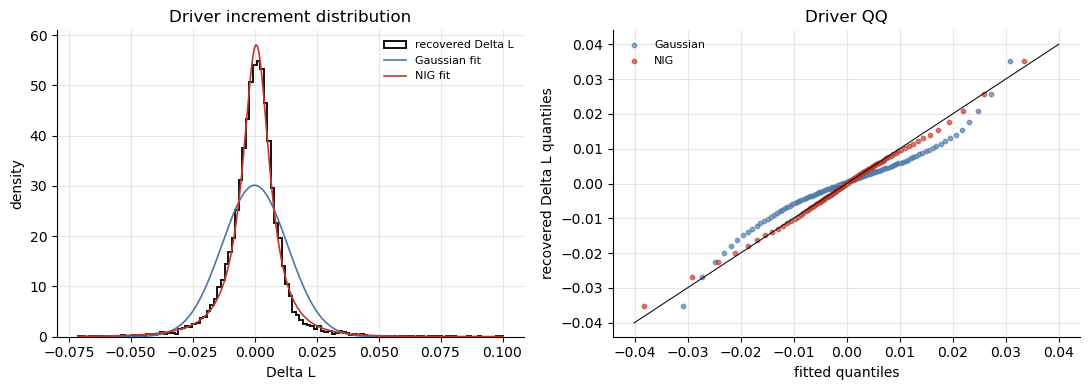

Saved: price_carma54_driver_deltaL_fits.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0]
bins = np.linspace(np.quantile(dL, 0.001), np.quantile(dL, 0.999), 120)
x = np.linspace(bins[0], bins[-1], 700)
ax.hist(dL, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="recovered Delta L")
ax.plot(x, norm.pdf(x, gaussian_driver["mean"], gaussian_driver["std"]),
        color="#4c78a8", lw=1.2, label="Gaussian fit")
ax.plot(x, norminvgauss.pdf(x, nig_driver["scipy_a"], nig_driver["scipy_b"],
                            loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        color="#c0392b", lw=1.2, label="NIG fit")
ax.set_title("Driver increment distribution")
ax.set_xlabel("Delta L")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
obs_q = np.quantile(dL, probs)
gauss_q = norm.ppf(probs, gaussian_driver["mean"], gaussian_driver["std"])
nig_q = norminvgauss.ppf(probs, nig_driver["scipy_a"], nig_driver["scipy_b"],
                         loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"])
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("Driver QQ")
ax.set_xlabel("fitted quantiles")
ax.set_ylabel("recovered Delta L quantiles")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_driver_deltaL_fits.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

## 5. Simulate selected CARMA model with fitted drivers

Gaussian driver simulation uses the exact sampled CARMA transition.

For NIG, the exact one-hour state shock is the stochastic integral

`int_0^1 exp(A(1-u)) e dL_u`.

The notebook uses one NIG driver increment per hour and a midpoint kernel for a simple diagnostic. It does not simulate sub-hour paths and should not be read as an exact NIG transition likelihood.


In [13]:
def simulate_gaussian_carma_exact(A, b_vec, F, Q_base, Pi1, ep, driver_fit,
                                  n_steps, n_paths, seed=20260621):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    m_rate = driver_fit["m_rate"]
    nu2_rate = driver_fit["nu2_rate"]

    state_mean = m_rate * np.linalg.solve(-A, ep)
    pi_sqrt = psd_sqrt(Pi1)
    q_sqrt = psd_sqrt(Q_base)
    g = np.linalg.solve(A, (F - np.eye(p)) @ ep)

    X = state_mean + np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ pi_sqrt.T)
    Y = np.empty((n_paths, n_steps))

    for t in range(n_steps):
        shocks = np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ q_sqrt.T)
        X = X @ F.T + m_rate * g + shocks
        Y[:, t] = X @ b_vec

    return Y


def simulate_nig_carma_midpoint(A, b_vec, F, ep, nig_fit,
                                n_steps, n_paths, burnin=5000, seed=20260622):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    shock_vec = expm(A * 0.5) @ ep
    mean_dL = nig_fit["mean"]
    state_mean = np.linalg.solve(np.eye(p) - F, shock_vec * mean_dL)

    X = np.tile(state_mean, (n_paths, 1))
    Y = np.empty((n_paths, n_steps))

    dL_all = norminvgauss.rvs(
        nig_fit["scipy_a"],
        nig_fit["scipy_b"],
        loc=nig_fit["scipy_loc"],
        scale=nig_fit["scipy_scale"],
        size=(n_paths, n_steps + burnin),
        random_state=rng,
    )

    out_i = 0
    for t in range(n_steps + burnin):
        X = X @ F.T + dL_all[:, t, None] * shock_vec
        if t >= burnin:
            Y[:, out_i] = X @ b_vec
            out_i += 1

    return Y, dL_all[:, burnin:]


N_PATHS = 250
gaussian_paths = simulate_gaussian_carma_exact(
    A, b_vec, F, Q_base, Pi1, ep, gaussian_driver,
    n_steps=N, n_paths=N_PATHS, seed=20260621,
)
nig_paths, nig_driver_draws = simulate_nig_carma_midpoint(
    A, b_vec, F, ep, nig_driver,
    n_steps=N, n_paths=N_PATHS, burnin=5000, seed=20260622,
)

gaussian_delta_y = np.diff(gaussian_paths, axis=1)
nig_delta_y = np.diff(nig_paths, axis=1)

print(f"Gaussian exact CARMA paths: {gaussian_paths.shape}")
print(f"NIG midpoint CARMA paths  : {nig_paths.shape}")
print(f"Gaussian Y mean/std       : {gaussian_paths.mean():.6e} / {gaussian_paths.std(ddof=0):.6e}")
print(f"NIG Y mean/std            : {nig_paths.mean():.6e} / {nig_paths.std(ddof=0):.6e}")
print(f"Observed Y mean/std       : {pr.mean():.6e} / {pr.std(ddof=0):.6e}")

Gaussian exact CARMA paths: (250, 26305)
NIG midpoint CARMA paths  : (250, 26305)
Gaussian Y mean/std       : 6.099367e-04 / 3.454280e-02
NIG Y mean/std            : 4.154886e-04 / 3.179939e-02
Observed Y mean/std       : -4.644104e-07 / 3.545192e-02


In [14]:
summary = pd.DataFrame({
    "observed_Y": distribution_summary(pr),
    "gaussian_CARMA_Y": distribution_summary(gaussian_paths),
    "nig_CARMA_Y": distribution_summary(nig_paths),
    "observed_DeltaY": distribution_summary(obs_delta_y),
    "gaussian_CARMA_DeltaY": distribution_summary(gaussian_delta_y),
    "nig_CARMA_DeltaY": distribution_summary(nig_delta_y),
    "recovered_DeltaL": distribution_summary(dL),
    "nig_simulated_DeltaL": distribution_summary(nig_driver_draws),
}).T

summary_path = OUT / f"price_{model_tag}_distribution_summary.csv"
summary.to_csv(summary_path)
print(summary.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"\nSaved: {summary_path}")

                               mean          std           q01           q05        median          q95          q99          skew  excess_kurtosis
observed_Y            -4.644104e-07 3.545192e-02 -8.252914e-02 -5.970823e-02  3.420037e-03 4.725925e-02 7.915109e-02  4.632184e-01     1.787167e+01
gaussian_CARMA_Y       6.099367e-04 3.454280e-02 -7.970194e-02 -5.616529e-02  5.895245e-04 5.750243e-02 8.108123e-02  3.260258e-03    -1.592436e-03
nig_CARMA_Y            4.154886e-04 3.179939e-02 -7.842860e-02 -5.225524e-02  9.061543e-04 5.146557e-02 7.475651e-02 -1.108209e-01     5.197962e-01
observed_DeltaY        2.432794e-06 1.295224e-02 -3.466270e-02 -1.708008e-02  2.865412e-04 1.539432e-02 3.622558e-02  3.503203e-01     8.057773e+01
gaussian_CARMA_DeltaY  9.767175e-08 1.299467e-02 -3.020465e-02 -2.137287e-02 -6.406503e-06 2.138194e-02 3.022676e-02  1.895154e-03    -1.509599e-03
nig_CARMA_DeltaY       9.117378e-08 1.190093e-02 -3.662611e-02 -1.828189e-02  3.296272e-04 1.712798e-02 3.230505

In [15]:
max_lag = 336
lags = np.arange(max_lag + 1)
acf_obs = acf_1d(pr, max_lag)
acf_gaussian = np.mean([acf_1d(path, max_lag) for path in gaussian_paths], axis=0)
acf_nig = np.mean([acf_1d(path, max_lag) for path in nig_paths], axis=0)

acf_diag_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
acf_table = pd.DataFrame({
    "lag": acf_diag_lags,
    "observed": acf_obs[acf_diag_lags],
    "gaussian_CARMA": acf_gaussian[acf_diag_lags],
    "nig_CARMA": acf_nig[acf_diag_lags],
})
print(acf_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

 lag  observed  gaussian_CARMA  nig_CARMA
   1  0.933189        0.927502   0.927806
   2  0.840121        0.859951   0.860520
   3  0.764942        0.796984   0.797699
   6  0.622077        0.635007   0.636141
  12  0.513318        0.456703   0.457869
  24  0.521936        0.431807   0.435581
  48  0.313737        0.310267   0.313106
  72  0.271502        0.237136   0.240947
 168  0.167746        0.125601   0.127637
 336  0.150791        0.090174   0.089737


## 6. Posterior predictive checks

These checks compare the realised empirical path with the distribution of statistics obtained from simulated CARMA paths. The key question is whether the observed statistic is typical under the model, not only whether two histograms look similar.


In [16]:
PPC_LAGS = [1, 6, 24, 72, 168, 336]


def acf_selected_lags(x, lags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    vals = []
    for lag in lags:
        if lag <= 0:
            vals.append(1.0)
        elif lag >= len(x) or denom <= 0.0:
            vals.append(np.nan)
        else:
            vals.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.array(vals, dtype=float)


def skew_and_excess_kurtosis(x):
    x = np.asarray(x, dtype=float)
    z = x - x.mean()
    sd = z.std(ddof=0)
    if sd <= 0.0:
        return np.nan, np.nan
    z = z / sd
    return float(np.mean(z ** 3)), float(np.mean(z ** 4) - 3.0)


def path_ppc_stats(y, lags=PPC_LAGS):
    y = np.asarray(y, dtype=float)
    dy = np.diff(y)
    skew_y, kurt_y = skew_and_excess_kurtosis(y)
    _, kurt_dy = skew_and_excess_kurtosis(dy)

    out = {
        "Y_std": float(np.std(y, ddof=0)),
        "Y_skew": skew_y,
        "Y_excess_kurtosis": kurt_y,
        "Y_q01": float(np.quantile(y, 0.01)),
        "Y_q05": float(np.quantile(y, 0.05)),
        "Y_q95": float(np.quantile(y, 0.95)),
        "Y_q99": float(np.quantile(y, 0.99)),
        "DeltaY_std": float(np.std(dy, ddof=0)),
        "DeltaY_excess_kurtosis": kurt_dy,
        "DeltaY_q01": float(np.quantile(dy, 0.01)),
        "DeltaY_q99": float(np.quantile(dy, 0.99)),
    }

    acf_y = acf_selected_lags(y, lags)
    acf_dy = acf_selected_lags(dy, lags)
    for lag, val in zip(lags, acf_y):
        out[f"ACF_Y_{lag}h"] = float(val)
    for lag, val in zip(lags, acf_dy):
        out[f"ACF_DeltaY_{lag}h"] = float(val)
    return pd.Series(out)


def simulated_ppc_stats(paths, lags=PPC_LAGS):
    rows = [path_ppc_stats(path, lags=lags) for path in np.asarray(paths)]
    return pd.DataFrame(rows)


def posterior_predictive_table(observed_stats, simulated_stats, model):
    rows = []
    for metric, observed in observed_stats.items():
        sims = simulated_stats[metric].dropna().to_numpy(float)
        q025, q50, q975 = np.quantile(sims, [0.025, 0.50, 0.975])
        obs_percentile = float(np.mean(sims <= observed))
        two_sided_p = float(min(1.0, 2.0 * min(obs_percentile, 1.0 - obs_percentile)))
        rows.append({
            "model": model,
            "metric": metric,
            "observed": float(observed),
            "sim_mean": float(np.mean(sims)),
            "sim_sd": float(np.std(sims, ddof=1)),
            "sim_q025": float(q025),
            "sim_q50": float(q50),
            "sim_q975": float(q975),
            "obs_percentile": obs_percentile,
            "two_sided_p": two_sided_p,
            "inside_95": bool(q025 <= observed <= q975),
            "n_paths": int(len(sims)),
        })
    return pd.DataFrame(rows)


observed_ppc = path_ppc_stats(pr)
gaussian_ppc_paths = simulated_ppc_stats(gaussian_paths)
nig_ppc_paths = simulated_ppc_stats(nig_paths)

ppc_table = pd.concat([
    posterior_predictive_table(observed_ppc, gaussian_ppc_paths, "Gaussian CARMA"),
    posterior_predictive_table(observed_ppc, nig_ppc_paths, "NIG CARMA"),
], ignore_index=True)

ppc_path = OUT / f"price_{model_tag}_posterior_predictive_checks.csv"
ppc_table.to_csv(ppc_path, index=False)

display_cols = [
    "metric",
    "observed",
    "sim_mean",
    "sim_q025",
    "sim_q975",
    "obs_percentile",
    "two_sided_p",
    "inside_95",
]

print("NIG CARMA posterior predictive checks")
print(
    ppc_table.loc[ppc_table["model"] == "NIG CARMA", display_cols]
    .to_string(index=False, float_format=lambda v: f"{v:.6e}")
)

print("\nMetrics outside the 95% posterior predictive envelope")
outliers = ppc_table.loc[~ppc_table["inside_95"], ["model"] + display_cols]
if len(outliers) == 0:
    print("None")
else:
    print(outliers.to_string(index=False, float_format=lambda v: f"{v:.6e}"))

print(f"\nSaved: {ppc_path}")


NIG CARMA posterior predictive checks
                metric      observed      sim_mean      sim_q025      sim_q975  obs_percentile  two_sided_p  inside_95
                 Y_std  3.545192e-02  3.136564e-02  2.972845e-02  3.341050e-02    9.960000e-01 8.000000e-03      False
                Y_skew  4.631920e-01 -1.164252e-01 -2.571036e-01  2.274411e-02    1.000000e+00 0.000000e+00      False
     Y_excess_kurtosis  1.786805e+01  5.313362e-01  2.408407e-01  8.885017e-01    1.000000e+00 0.000000e+00      False
                 Y_q01 -8.252914e-02 -7.746845e-02 -8.878607e-02 -6.644545e-02    2.040000e-01 4.080000e-01       True
                 Y_q05 -5.970823e-02 -5.158693e-02 -6.166725e-02 -4.035414e-02    6.000000e-02 1.200000e-01       True
                 Y_q95  4.725925e-02  5.072368e-02  4.001041e-02  6.212466e-02    2.760000e-01 5.520000e-01       True
                 Y_q99  7.915109e-02  7.364924e-02  6.178681e-02  8.576196e-02    8.320000e-01 3.360000e-01       True
          

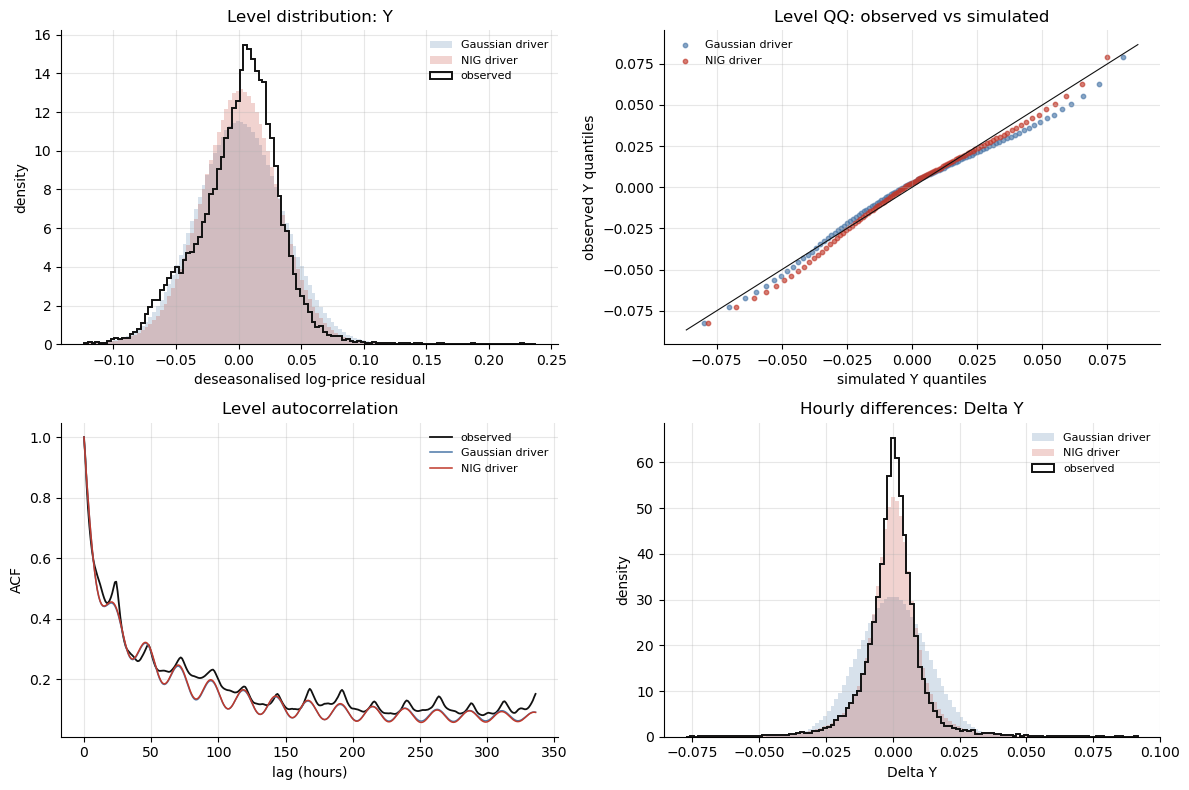

Saved: price_carma54_level_distribution_comparison.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0, 0]
bins_y = np.linspace(
    min(np.quantile(pr, 0.001), np.quantile(gaussian_paths, 0.001), np.quantile(nig_paths, 0.001)),
    max(np.quantile(pr, 0.999), np.quantile(gaussian_paths, 0.999), np.quantile(nig_paths, 0.999)),
    120,
)
ax.hist(gaussian_paths.ravel(), bins=bins_y, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_paths.ravel(), bins=bins_y, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(pr, bins=bins_y, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
ax.set_title("Level distribution: Y")
ax.set_xlabel("deseasonalised log-price residual")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(pr, probs)
gauss_q = np.quantile(gaussian_paths.ravel(), probs)
nig_q = np.quantile(nig_paths.ravel(), probs)
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("Level QQ: observed vs simulated")
ax.set_xlabel("simulated Y quantiles")
ax.set_ylabel("observed Y quantiles")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.plot(lags, acf_obs, color="#111111", lw=1.3, label="observed")
ax.plot(lags, acf_gaussian, color="#4c78a8", lw=1.1, label="Gaussian driver")
ax.plot(lags, acf_nig, color="#c0392b", lw=1.1, label="NIG driver")
ax.set_title("Level autocorrelation")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("ACF")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
bins_dy = np.linspace(
    min(np.quantile(obs_delta_y, 0.001), np.quantile(gaussian_delta_y, 0.001), np.quantile(nig_delta_y, 0.001)),
    max(np.quantile(obs_delta_y, 0.999), np.quantile(gaussian_delta_y, 0.999), np.quantile(nig_delta_y, 0.999)),
    120,
)
ax.hist(gaussian_delta_y.ravel(), bins=bins_dy, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_delta_y.ravel(), bins=bins_dy, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(obs_delta_y, bins=bins_dy, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
ax.set_title("Hourly differences: Delta Y")
ax.set_xlabel("Delta Y")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_level_distribution_comparison.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

## 7. Final log-price and price checks

The final observed log-price is `log_price_seasonal + log_price_resid`. This section compares the empirical final series with the theoretical seasonal component plus simulated CARMA stochastic components. It then maps back to raw prices with `price = exp(log_price) - shift`.


                           mean          std           q01           q05       median          q95          q99          skew  excess_kurtosis    delta_std     delta_q01    delta_q99
observed_log_price 6.990761e+00 4.669728e-02  6.892655e+00  6.907745e+00 6.994043e+00 7.056163e+00 7.108452e+00  2.383657e-01     1.113257e+01 1.821222e-02 -4.686418e-02 5.640149e-02
gaussian_log_price 6.991371e+00 4.601376e-02  6.879730e+00  6.914860e+00 6.991871e+00 7.066048e+00 7.096977e+00 -8.161735e-02     1.327379e-01 1.832995e-02 -4.068880e-02 4.523226e-02
nig_log_price      6.991177e+00 4.394476e-02  6.881519e+00  6.917434e+00 6.992013e+00 7.061696e+00 7.091655e+00 -1.370794e-01     2.973443e-01 1.757067e-02 -4.396147e-02 4.478145e-02
observed_price     8.773980e+01 5.146810e+01 -1.498640e+01 -1.000000e-02 9.012000e+01 1.599860e+02 2.222540e+02  1.193021e+00     1.610672e+01 2.066981e+01 -5.252790e+01 6.145790e+01
gaussian_price     8.836126e+01 5.001592e+01 -2.763651e+01  7.129953e+00 8.775453e+01

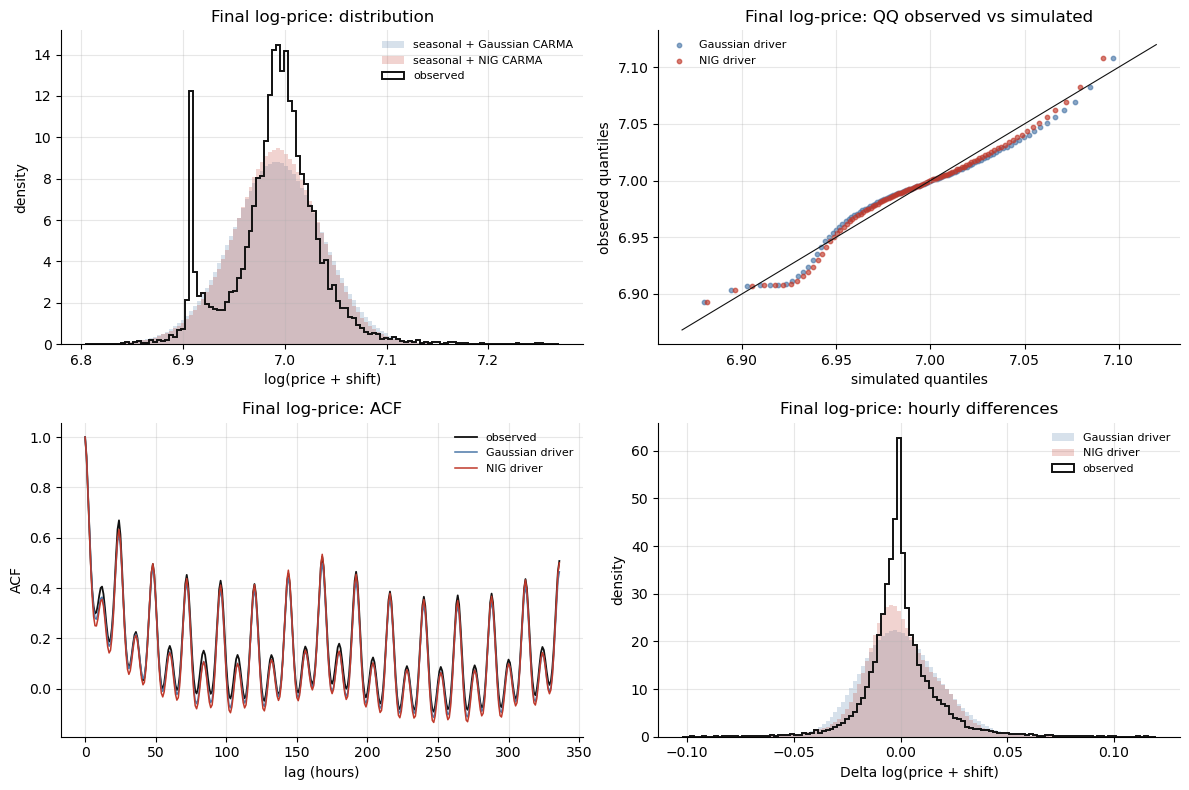

Saved: price_carma54_final_logprice_comparison.png


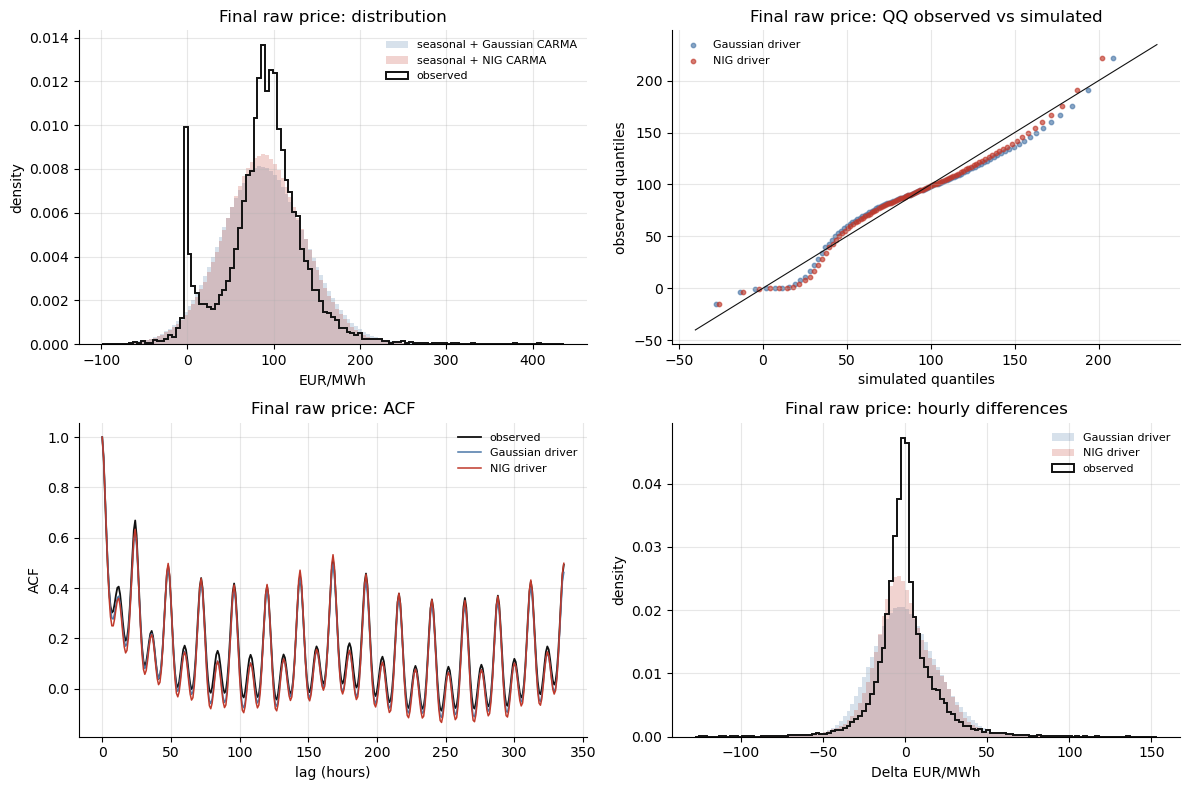

Saved: price_carma54_final_price_comparison.png


In [18]:
def final_distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    dx = np.diff(x)
    return pd.Series({
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=0)),
        "q01": float(np.quantile(x, 0.01)),
        "q05": float(np.quantile(x, 0.05)),
        "median": float(np.quantile(x, 0.50)),
        "q95": float(np.quantile(x, 0.95)),
        "q99": float(np.quantile(x, 0.99)),
        "skew": float(pd.Series(x).skew()),
        "excess_kurtosis": float(pd.Series(x).kurt()),
        "delta_std": float(np.std(dx, ddof=0)),
        "delta_q01": float(np.quantile(dx, 0.01)),
        "delta_q99": float(np.quantile(dx, 0.99)),
    })


def plot_final_series_checks(observed, gaussian_sim, nig_sim, observed_delta, gaussian_delta, nig_delta,
                             acf_max_lag, title_prefix, xlabel, delta_xlabel, fig_path):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    probs = np.linspace(0.01, 0.99, 99)

    ax = axes[0, 0]
    bins = np.linspace(
        min(np.quantile(observed, 0.001), np.quantile(gaussian_sim, 0.001), np.quantile(nig_sim, 0.001)),
        max(np.quantile(observed, 0.999), np.quantile(gaussian_sim, 0.999), np.quantile(nig_sim, 0.999)),
        120,
    )
    ax.hist(gaussian_sim.ravel(), bins=bins, density=True, color="#4c78a8", alpha=0.22, label="seasonal + Gaussian CARMA")
    ax.hist(nig_sim.ravel(), bins=bins, density=True, color="#c0392b", alpha=0.22, label="seasonal + NIG CARMA")
    ax.hist(observed, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
    ax.set_title(f"{title_prefix}: distribution")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[0, 1]
    obs_q = np.quantile(observed, probs)
    gauss_q = np.quantile(gaussian_sim.ravel(), probs)
    nig_q = np.quantile(nig_sim.ravel(), probs)
    lim_lo = min(obs_q.min(), gauss_q.min(), nig_q.min())
    lim_hi = max(obs_q.max(), gauss_q.max(), nig_q.max())
    pad = 0.05 * (lim_hi - lim_lo)
    ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
    ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
    ax.plot([lim_lo - pad, lim_hi + pad], [lim_lo - pad, lim_hi + pad], color="#111111", lw=0.8)
    ax.set_title(f"{title_prefix}: QQ observed vs simulated")
    ax.set_xlabel("simulated quantiles")
    ax.set_ylabel("observed quantiles")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 0]
    lag_grid = np.arange(acf_max_lag + 1)
    acf_obs_final = acf_1d(observed, acf_max_lag)
    acf_gauss_final = np.mean([acf_1d(path, acf_max_lag) for path in gaussian_sim], axis=0)
    acf_nig_final = np.mean([acf_1d(path, acf_max_lag) for path in nig_sim], axis=0)
    ax.plot(lag_grid, acf_obs_final, color="#111111", lw=1.3, label="observed")
    ax.plot(lag_grid, acf_gauss_final, color="#4c78a8", lw=1.1, label="Gaussian driver")
    ax.plot(lag_grid, acf_nig_final, color="#c0392b", lw=1.1, label="NIG driver")
    ax.set_title(f"{title_prefix}: ACF")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("ACF")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 1]
    bins_delta = np.linspace(
        min(np.quantile(observed_delta, 0.001), np.quantile(gaussian_delta, 0.001), np.quantile(nig_delta, 0.001)),
        max(np.quantile(observed_delta, 0.999), np.quantile(gaussian_delta, 0.999), np.quantile(nig_delta, 0.999)),
        120,
    )
    ax.hist(gaussian_delta.ravel(), bins=bins_delta, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
    ax.hist(nig_delta.ravel(), bins=bins_delta, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
    ax.hist(observed_delta, bins=bins_delta, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
    ax.set_title(f"{title_prefix}: hourly differences")
    ax.set_xlabel(delta_xlabel)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.savefig(fig_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path.name}")


if gaussian_paths.shape[1] != N or nig_paths.shape[1] != N:
    raise ValueError(
        f"Simulated paths length mismatch: gaussian={gaussian_paths.shape[1]}, "
        f"nig={nig_paths.shape[1]}, observed={N}"
    )

gaussian_log_price_paths = log_price_seasonal[None, :] + gaussian_paths
nig_log_price_paths = log_price_seasonal[None, :] + nig_paths

gaussian_price_paths = np.exp(gaussian_log_price_paths) - price_shift
nig_price_paths = np.exp(nig_log_price_paths) - price_shift

gaussian_delta_log_price = np.diff(gaussian_log_price_paths, axis=1)
nig_delta_log_price = np.diff(nig_log_price_paths, axis=1)
gaussian_delta_price = np.diff(gaussian_price_paths, axis=1)
nig_delta_price = np.diff(nig_price_paths, axis=1)

final_summary = pd.DataFrame({
    "observed_log_price": final_distribution_summary(log_price_obs),
    "gaussian_log_price": final_distribution_summary(gaussian_log_price_paths),
    "nig_log_price": final_distribution_summary(nig_log_price_paths),
    "observed_price": final_distribution_summary(price_obs),
    "gaussian_price": final_distribution_summary(gaussian_price_paths),
    "nig_price": final_distribution_summary(nig_price_paths),
}).T

final_summary_path = OUT / f"price_{model_tag}_final_logprice_price_summary.csv"
final_summary.to_csv(final_summary_path)
print(final_summary.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"\nSaved: {final_summary_path}")

plot_final_series_checks(
    observed=log_price_obs,
    gaussian_sim=gaussian_log_price_paths,
    nig_sim=nig_log_price_paths,
    observed_delta=obs_delta_log_price,
    gaussian_delta=gaussian_delta_log_price,
    nig_delta=nig_delta_log_price,
    acf_max_lag=336,
    title_prefix="Final log-price",
    xlabel="log(price + shift)",
    delta_xlabel="Delta log(price + shift)",
    fig_path=FIG / f"price_{model_tag}_final_logprice_comparison.png",
)

plot_final_series_checks(
    observed=price_obs,
    gaussian_sim=gaussian_price_paths,
    nig_sim=nig_price_paths,
    observed_delta=obs_delta_price,
    gaussian_delta=gaussian_delta_price,
    nig_delta=nig_delta_price,
    acf_max_lag=336,
    title_prefix="Final raw price",
    xlabel="EUR/MWh",
    delta_xlabel="Delta EUR/MWh",
    fig_path=FIG / f"price_{model_tag}_final_price_comparison.png",
)


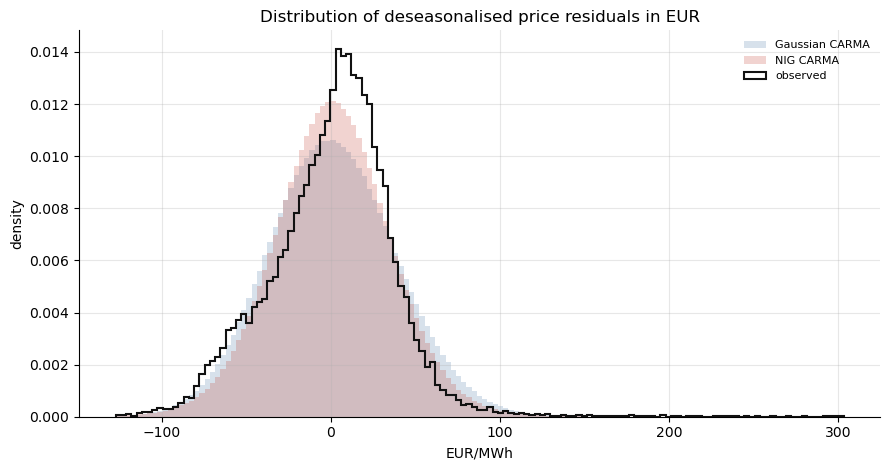

,mean,std,q01,q05,median,q95,q99,skew,excess_kurtosis
observed_EUR_residual,6.905952e-01,3.948561e+01,-8.700011e+01,-6.276500e+01,3.727579e+00,5.201493e+01,9.187547e+01,1.869218e+00,2.948291e+01
gaussian_CARMA_EUR_residual,1.312052e+00,3.762776e+01,-8.342085e+01,-5.939245e+01,6.399149e-01,6.435173e+01,9.198088e+01,1.075555e-01,2.962259e-02
nig_CARMA_EUR_residual,9.985374e-01,3.456915e+01,-8.210485e+01,-5.538006e+01,9.844785e-01,5.743935e+01,8.450455e+01,7.836465e-03,4.999196e-01


Saved: price_carma54_eur_simulated_residual_distribution_hist.png


In [19]:
# EUR-scale distribution histograms: observed vs simulated CARMA residuals
# log convention: log_price = log(price_raw + 1000)

PRICE_SHIFT = 1000.0

n_fit = min(
    len(pr),
    len(log_price_seasonal),
    len(price_obs),
    gaussian_paths.shape[1],
    nig_paths.shape[1],
)

seasonal_log = np.asarray(log_price_seasonal[:n_fit], dtype=float)
obs_log_resid = np.asarray(pr[:n_fit], dtype=float)
price_raw_eur = np.asarray(price_obs[:n_fit], dtype=float)

seasonal_price_eur = np.exp(seasonal_log) - PRICE_SHIFT

obs_price_from_log_eur = np.exp(seasonal_log + obs_log_resid) - PRICE_SHIFT
obs_resid_eur = obs_price_from_log_eur - seasonal_price_eur

gaussian_price_eur = np.exp(seasonal_log[None, :] + gaussian_paths[:, :n_fit]) - PRICE_SHIFT
nig_price_eur = np.exp(seasonal_log[None, :] + nig_paths[:, :n_fit]) - PRICE_SHIFT

gaussian_resid_eur = gaussian_price_eur - seasonal_price_eur[None, :]
nig_resid_eur = nig_price_eur - seasonal_price_eur[None, :]

bins = np.linspace(
    min(
        np.quantile(obs_resid_eur, 0.001),
        np.quantile(gaussian_resid_eur, 0.001),
        np.quantile(nig_resid_eur, 0.001),
    ),
    max(
        np.quantile(obs_resid_eur, 0.999),
        np.quantile(gaussian_resid_eur, 0.999),
        np.quantile(nig_resid_eur, 0.999),
    ),
    140,
)

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.hist(gaussian_resid_eur.ravel(), bins=bins, density=True,
        color="#4c78a8", alpha=0.22, label="Gaussian CARMA")
ax.hist(nig_resid_eur.ravel(), bins=bins, density=True,
        color="#c0392b", alpha=0.22, label="NIG CARMA")
ax.hist(obs_resid_eur, bins=bins, density=True, histtype="step",
        color="#111111", lw=1.5, label="observed")

ax.set_title("Distribution of deseasonalised price residuals in EUR")
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_eur_simulated_residual_distribution_hist.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()

summary_eur = pd.DataFrame({
    "observed_EUR_residual": distribution_summary(obs_resid_eur),
    "gaussian_CARMA_EUR_residual": distribution_summary(gaussian_resid_eur),
    "nig_CARMA_EUR_residual": distribution_summary(nig_resid_eur),
}).T

display(summary_eur.style.format("{:.6e}"))
print(f"Saved: {fig_path.name}")

## 8. Key diagnostic identity

If the simulated levels have too much variance but their hourly differences look close, the likely reason is an autocorrelation compensation:

`Var(Delta Y) = 2 Var(Y) (1 - rho_1)`.

In [20]:
def level_delta_identity(name, y):
    y = np.asarray(y, dtype=float).ravel()
    dy = np.diff(y)
    var_y = float(np.var(y))
    var_dy = float(np.var(dy))
    rho1 = 1.0 - var_dy / (2.0 * var_y)
    return pd.Series({
        "std_Y": np.sqrt(var_y),
        "std_DeltaY": np.sqrt(var_dy),
        "rho1_implied": rho1,
        "varY_over_observed": var_y / np.var(pr),
        "varDeltaY_over_observed": var_dy / np.var(obs_delta_y),
    }, name=name)


identity = pd.DataFrame([
    level_delta_identity("observed", pr),
    level_delta_identity("gaussian_CARMA", gaussian_paths),
    level_delta_identity("nig_CARMA", nig_paths),
])

print(identity.to_string(float_format=lambda v: f"{v:.6e}"))

                      std_Y   std_DeltaY  rho1_implied  varY_over_observed  varDeltaY_over_observed
observed       3.545192e-02 1.295224e-02  9.332609e-01        1.000000e+00             1.000000e+00
gaussian_CARMA 3.454280e-02 1.299799e-02  9.292042e-01        9.493698e-01             1.007077e+00
nig_CARMA      3.179939e-02 1.190447e-02  9.299267e-01        8.045594e-01             8.447545e-01


In [21]:
# Clear text export of final CARMA + QMLE + NIG parameters,
# including real/complex half-lives and complex periods.

def fmt_float(x, nd=12):
    x = float(x)
    if abs(x) >= 1e4 or (abs(x) > 0 and abs(x) < 1e-4):
        return f"{x:.{nd}e}"
    return f"{x:.{nd}f}"


def root_kind(z, tol=1e-10):
    return "real" if abs(complex(z).imag) < tol else "complex"


def root_half_life_h(z):
    z = complex(z)
    return float(np.log(2.0) / (-z.real))


def root_period_h(z, tol=1e-10):
    z = complex(z)
    if abs(z.imag) < tol:
        return np.nan
    return float(2.0 * np.pi / abs(z.imag))


def print_coefficients_text(title, prefix, coeffs, start_idx):
    print(title)
    for i, v in enumerate(coeffs, start=start_idx):
        print(f"  {prefix}{i} = {fmt_float(v)}")


def print_root_block(title, roots_arr):
    roots_arr = np.asarray(roots_arr, dtype=complex)
    real_roots = [z for z in roots_arr if abs(z.imag) < 1e-10]
    complex_roots_pos = [z for z in roots_arr if z.imag > 1e-10]

    print(title)

    print("  Real roots:")
    if len(real_roots) == 0:
        print("    none")
    else:
        for j, z in enumerate(sorted(real_roots, key=lambda w: root_half_life_h(w)), start=1):
            hl_h = root_half_life_h(z)
            print(
                f"    {j}. root = {fmt_float(z.real)}"
                f" | half_life_h = {fmt_float(hl_h, 6)}"
                f" | half_life_d = {fmt_float(hl_h / 24.0, 6)}"
            )

    print("  Complex conjugate pairs:")
    if len(complex_roots_pos) == 0:
        print("    none")
    else:
        for j, z in enumerate(sorted(complex_roots_pos, key=lambda w: root_period_h(w)), start=1):
            hl_h = root_half_life_h(z)
            period_h = root_period_h(z)
            omega = abs(z.imag)
            print(
                f"    {j}. roots = {fmt_float(z.real)} +/- {fmt_float(omega)} i"
                f" | half_life_h = {fmt_float(hl_h, 6)}"
                f" | half_life_d = {fmt_float(hl_h / 24.0, 6)}"
                f" | period_h = {fmt_float(period_h, 6)}"
                f" | omega = {fmt_float(omega)}"
            )


print("=" * 88)
print("FINAL GERMANY PRICE CARMA-QMLE + NIG DRIVER PARAMETERS")
print("=" * 88)

print("\nMODEL")
print(f"  order             = CARMA({p},{q})")
print(f"  Delta             = {fmt_float(Delta, 6)} hour")
print("  AR convention     = a(z) = z^p + a1 z^(p-1) + ... + ap")
print("  MA convention     = b(z) = b0 + b1 z + ... + bq z^q, with bq = 1")

print("\nQMLE")
print(f"  m_hat             = {fmt_float(m_hat)}")
print(f"  nu2_hat           = {fmt_float(nu2_hat)}")
print(f"  sqrt_nu2_hat      = {fmt_float(np.sqrt(nu2_hat))}")
print(f"  stationary_mean   = {fmt_float(m_hat * dc_gain)}")
if "qmle" in globals():
    print(f"  loglik_qmle       = {fmt_float(qmle['loglik'], 6)}")
    print(f"  reduced_lik       = {fmt_float(qmle['reduced_likelihood'], 12)}")
if "opt" in globals() and isinstance(opt, dict) and "acf_mse" in opt:
    print(f"  acf_mse_diag      = {fmt_float(opt['acf_mse'], 12)}")

print("\nCARMA POLYNOMIAL COEFFICIENTS")
print_coefficients_text("  AR coefficients:", "a", ar_coefficients, 1)
print_coefficients_text("  MA coefficients:", "b", b_coefficients, 0)
print(f"  MA normalisation check: b{q} = {fmt_float(b_coefficients[-1])}")

print("\nCARMA ROOTS, HALF-LIVES, PERIODS")
print_root_block("  AR roots of a(z):", roots_complex)
print_root_block("  MA roots of b(z):", ma_roots_complex)

print("\nCOMPACT HALF-LIFE SUMMARY")
ar_real_sorted, ar_complex_pos = split_real_and_complex_roots(roots_complex)
ma_real_sorted, ma_complex_pos = split_real_and_complex_roots(ma_roots_complex)

ar_real_hl = half_life_from_kappa(-ar_real_sorted)
ma_real_hl = half_life_from_kappa(-ma_real_sorted)

print("  AR real half-lives:")
for name, hl in zip(["fast", "mid", "slow"], ar_real_hl):
    print(f"    {name:5s}: {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d")

for j, z in enumerate(ar_complex_pos, start=1):
    hl = root_half_life_h(z)
    period = root_period_h(z)
    print(
        f"  AR complex pair {j}: "
        f"half_life = {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d, "
        f"period = {fmt_float(period, 6)} h"
    )

print("  MA real half-lives:")
for j, hl in enumerate(ma_real_hl, start=1):
    print(f"    real {j}: {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d")

for j, z in enumerate(ma_complex_pos, start=1):
    hl = root_half_life_h(z)
    period = root_period_h(z)
    print(
        f"  MA complex pair {j}: "
        f"half_life = {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d, "
        f"period = {fmt_float(period, 6)} h"
    )

print("\nSTATE SPACE")
print("  observation vector b_vec:")
for i, v in enumerate(b_vec):
    print(f"    b_vec[{i}] = {fmt_float(v)}")
print(f"  DC gain b(0)/a(0) = {fmt_float(dc_gain)}")

print("\nNIG DRIVER FIT ON RECOVERED HOURLY DELTA L")
print("  Parametrisation: scipy.stats.norminvgauss(a, b, loc, scale)")
print(f"  scipy_a           = {fmt_float(nig_driver['scipy_a'])}")
print(f"  scipy_b           = {fmt_float(nig_driver['scipy_b'])}")
print(f"  scipy_loc         = {fmt_float(nig_driver['scipy_loc'])}")
print(f"  scipy_scale       = {fmt_float(nig_driver['scipy_scale'])}")

print("\n  Equivalent NIG parameters:")
print(f"  mu                = {fmt_float(nig_driver['mu'])}")
print(f"  delta             = {fmt_float(nig_driver['delta'])}")
print(f"  alpha             = {fmt_float(nig_driver['alpha'])}")
print(f"  beta              = {fmt_float(nig_driver['beta'])}")
print(f"  gamma             = {fmt_float(nig_driver['gamma'])}")

print("\n  NIG moments:")
print(f"  mean              = {fmt_float(nig_driver['mean'])}")
print(f"  variance          = {fmt_float(nig_driver['variance'])}")
print(f"  std               = {fmt_float(nig_driver['std'])}")
print(f"  skew              = {fmt_float(nig_driver['skew'], 8)}")
print(f"  excess_kurtosis   = {fmt_float(nig_driver['excess_kurtosis'], 8)}")
print(f"  loglik            = {fmt_float(nig_driver['loglik'], 6)}")
print(f"  N                 = {int(nig_driver['N'])}")

if "gaussian_driver" in globals():
    print("\nGAUSSIAN DRIVER FIT ON RECOVERED HOURLY DELTA L")
    print(f"  mean              = {fmt_float(gaussian_driver['mean'])}")
    print(f"  variance          = {fmt_float(gaussian_driver['variance'])}")
    print(f"  std               = {fmt_float(gaussian_driver['std'])}")
    print(f"  m_rate            = {fmt_float(gaussian_driver['m_rate'])}")
    print(f"  nu2_rate          = {fmt_float(gaussian_driver['nu2_rate'])}")
    print(f"  N                 = {int(gaussian_driver['N'])}")

print("\nFILES")
if "qmle_path" in globals():
    print(f"  QMLE json         = {qmle_path}")
if "driver_fits_path" in globals():
    print(f"  driver fits json  = {driver_fits_path}")

print("=" * 88)

FINAL GERMANY PRICE CARMA-QMLE + NIG DRIVER PARAMETERS

MODEL
  order             = CARMA(5,4)
  Delta             = 1.000000 hour
  AR convention     = a(z) = z^p + a1 z^(p-1) + ... + ap
  MA convention     = b(z) = b0 + b1 z + ... + bq z^q, with bq = 1

QMLE
  m_hat             = 8.473621453232e-06
  nu2_hat           = 0.000175361466
  sqrt_nu2_hat      = 0.013242411630
  stationary_mean   = 0.000583450406
  loglik_qmle       = 7.770905e+04
  reduced_lik       = -8.746187152769
  acf_mse_diag      = 0.000698783544

CARMA POLYNOMIAL COEFFICIENTS
  AR coefficients:
  a1 = 0.180878007791
  a2 = 0.072955388459
  a3 = 0.011876286348
  a4 = 0.000206776833
  a5 = 7.105208972921e-08
  MA coefficients:
  b0 = 4.892284940010e-06
  b1 = 0.003871537896
  b2 = 0.067247596781
  b3 = 0.080860692901
  b4 = 1.000000000000
  MA normalisation check: b4 = 1.000000000000

CARMA ROOTS, HALF-LIVES, PERIODS
  AR roots of a(z):
  Real roots:
    1. root = -0.153230806644 | half_life_h = 4.523550 | half_life